# 23_04 — Evaluación predictiva · Río Mapocho · nivel · **barrido en $M$**

Paso **3b** del ciclo. Supone que `23_03_convergencia` dio veredicto OK **en
cada punto del barrido**; si las cadenas de un $M$ no convergieron, sus cifras
aquí no significan nada.

## Qué se reporta

- Predicción funcional a $h=1$ y su intervalo de credibilidad — se PERSISTEN, es lo que consume `23_05` 
- **Bloque A** (MAE, RMSE, error máximo) sobre la ventana móvil, y qué $M$ gana en cada ventana 
- **Bloque B** (Winkler, cobertura simultánea, cobertura puntual, MPIW) sobre la ventana móvil
- Muestra de predicciones: extractos regulares del test, y las peores ventanas según la métrica que se elija, con la curva anterior al lado
- Pobabilidades posteriores de inclusión (PIP), sin estructura verdadera
- Cuadro resumen: mínimo, máximo y promedio de cada métrica sobre la ventana
- Monitoreo univariado por componente FPCA: MAE, RMSE y MISE de cada score, por separado

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.


## 1. Imports, rutas y artefactos

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import (
    PropagadorFuncional, residuos_representacion,
    ruta_traza, leer_traza, ModeloTraza,   # convencion de trazas (§2)
)

from model_psbp_fd.fit import (
    mise,                                    # piso de truncamiento (§3)
    intervalo_muestral,                      # banda sobre los scores (§3)
    agrupar_momentos,                        # media/sd entre cadenas (§3)
    ventana_movil_scores, ventana_movil_funcional,   # el motor de §4/5/9
    indicador_cobertura,                     # I_t puntual (§8)
    indicador_cobertura_simultanea,          # I_t simultaneo (§8)
    matriz_pip, contraste_con_verdad,        # §7
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_extractos_curvas,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


In [3]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] 
# Identidad de la corrida. DEBE coincidir con 23_01, los otros notebooks y
# psbp_fd_iteracion.m: real_<serie>_v<ventana>_m<M>.
BASENAME, SERIE_ID, VENTANA_ID = "real", "nivel", 4
M_FPCA_LIST = (1, 2, 3)   # componentes FPCA; igual en 23_01, _03, _04, _05 y el .m

SALTAR_M_SIN_TRAZAS = True

PESOS_TAU = None

METRICA_PEORES = "rmse_f"   # cualquiera de METRICAS_MONITOR (nivel funcional)
N_PEORES = 5

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
assert len(set(M_FPCA_LIST)) == len(M_FPCA_LIST), "M_FPCA_LIST tiene repetidos."

EXPERIMENT_BASE = f"{BASENAME}_{SERIE_ID}_v{VENTANA_ID:02d}"


def experiment_id(M: int) -> str:
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "reales" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "reales" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "reales" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "reales" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "reales" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M      = {M: rutas(M) for M in M_FPCA_LIST}
PATH_BARRIDO = PROJECT_ROOT / "reports" / "reales" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}")
print(f"salidas cruzadas de M : {PATH_BARRIDO}   "
      "(ventana movil por M, prefijo 88_*)")


# Las 10 metricas del marco teorico 02_02_03, en su orden. No se agregan otras.
METRICAS_A = [
    (u"1. MAE  (L^1)",                     "mae_f"),
    (u"2. RMSE (L^2)",                     "rmse_f"),
    (u"3. E_max promedio por curva",       "linf_medio"),
    (u"4. E_max peor de la ventana",       "linf_max"),
]
METRICAS_B = [
    (u"5. MPIW",                           "mpiw"),
    (u"6. PICP puntual",                   "picp"),
    (u"7. PICPB curva completa",           "picp_simultaneo"),
    (u"8. Winkler",                        "winkler"),
    (u"9. Winkler max promedio",           "winkler_max_medio"),
    (u"10. Winkler max peor ventana",      "winkler_max_glob"),
]
METRICAS_MONITOR = METRICAS_A + METRICAS_B

print("")
print("metricas monitoreadas (nivel funcional, en orden):")
for _et, _cw in METRICAS_MONITOR:
    print("   %-40s  columna=%s" % (_et, _cw))
print("   + I_t puntual y simultaneo (series por origen)  ->  "
      "67_indicador_cobertura.csv")

# Columnas de cada bloque: §4 dibuja el A y §5 el B, sin mezclarlos.
METRICAS_A_COLS = [c for _, c in METRICAS_A]
METRICAS_B_COLS = [c for _, c in METRICAS_B]



barrido en M : [1, 2, 3]
  M=1  ->  real_nivel_v04_m01
  M=2  ->  real_nivel_v04_m02
  M=3  ->  real_nivel_v04_m03
salidas cruzadas de M : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v04_barrido_M   (ventana movil por M, prefijo 88_*)

metricas monitoreadas (nivel funcional, en orden):
   1. MAE  (L^1)                             columna=mae_f
   2. RMSE (L^2)                             columna=rmse_f
   3. E_max promedio por curva               columna=linf_medio
   4. E_max peor de la ventana               columna=linf_max
   5. MPIW                                   columna=mpiw
   6. PICP puntual                           columna=picp
   7. PICPB curva completa                   columna=picp_simultaneo
   8. Winkler                                columna=winkler
   9. Winkler max promedio                   columna=winkler_max_medio
   10. Winkler max peor ventana              columna=winkler_max_glob
   + I_t puntual y simultaneo (series p

In [4]:
# Estado por punto del barrido. Nada de lo que sigue usa variables globales del
# experimento: todo se lee de EST[M].
EST = {}
saltados = []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 23_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    dfs_test,  _        = cargar_datasets_ar(P, bloque="test")
    hp_json     = cargar_hiperparametros(P)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes.")
    assert manifest["scores_scale"] == "raw_fpca_scores"

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "dfs_test": dfs_test, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": manifest["cov_names"],
        "n_lags": int(manifest["n_lags"]),
        "T": int(manifest["T"]), "T0": int(manifest["T0"]),
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "burn": int(hp_json["mcmc_config"]["burn"]),
        # Parámetros de evaluación: se LEEN del artefacto, no se redeclaran.
        "nivel": float(eval_config.get("nivel_credibilidad", 0.95)),
        "modo_residuo": eval_config.get("modo_residuo", "ninguno"),
        "objetivo": eval_config.get("objetivo_evaluacion", "curva_verdadera"),
        "ventanas_w": list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40])),
    }
    EST[M]["n_post"] = EST[M]["mcmc_cfg"]["nsim"] - EST[M]["burn"]

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 23_01 primero."

for M, e in EST.items():
    print(f"M={M}  T={e['T']} T0={e['T0']} n_lags={e['n_lags']} "
          f"componentes={e['n_components']}  nivel={e['nivel']}  "
          f"modo_residuo={e['modo_residuo']!r}  objetivo={e['objetivo']!r}")
for M, motivo in saltados:
    print(f"  ! M={M} saltado: {motivo}")

# La comparación entre M sólo tiene sentido si el diseño de observación, la
# partición y el objetivo de evaluación son los mismos en todos los puntos: si
# no, las diferencias mezclarían el efecto de M con el de otra cosa.
_comun = {M: (e["T"], e["T0"], e["n_lags"], e["nivel"], e["modo_residuo"],
              e["objetivo"], tuple(e["ventanas_w"]), e["n_iter"],
              e["mcmc_cfg"]["nsim"], e["mcmc_cfg"]["N"], e["burn"])
          for M, e in EST.items()}
if len(set(_comun.values())) > 1:
    print("\n! Los puntos del barrido NO comparten diseño/evaluación:")
    for M, v in _comun.items():
        print(f"    M={M}: {v}")
    raise AssertionError(
        "El barrido en M exige T, T0, n_lags, nivel, modo_residuo, objetivo, "
        "ventanas y configuración MCMC idénticos. Regenera los puntos que "
        "difieren antes de comparar.")
print("\nOK todos los puntos comparten diseño de observación, partición, "
      "objetivo de evaluación y configuración MCMC.")

# Alias de las cantidades comunes, para no repetir EST[M][...] en cada celda.
T          = EST[next(iter(EST))]["T"]
T0         = EST[next(iter(EST))]["T0"]
N_LAGS     = EST[next(iter(EST))]["n_lags"]
NIVEL      = EST[next(iter(EST))]["nivel"]
MODO_RESIDUO = EST[next(iter(EST))]["modo_residuo"]
OBJETIVO   = EST[next(iter(EST))]["objetivo"]
VENTANAS_W = EST[next(iter(EST))]["ventanas_w"]
W_REF      = VENTANAS_W[len(VENTANAS_W) // 2]
print(f"ventanas w = {VENTANAS_W}   ·   referencia w={W_REF}")
print(f"IC de la curva: NIVEL = 1 - alpha = {NIVEL:.2f}   ->   alpha = {1 - NIVEL:.2f}   (cuantiles F^-1(alpha/2), F^-1(1 - alpha/2))")


M=1  T=1511 T0=1057 n_lags=1 componentes=1  nivel=0.95  modo_residuo='empirico'  objetivo='curva_observada'
M=2  T=1511 T0=1057 n_lags=1 componentes=2  nivel=0.95  modo_residuo='empirico'  objetivo='curva_observada'
M=3  T=1511 T0=1057 n_lags=1 componentes=3  nivel=0.95  modo_residuo='empirico'  objetivo='curva_observada'

OK todos los puntos comparten diseño de observación, partición, objetivo de evaluación y configuración MCMC.
ventanas w = [10, 20, 40]   ·   referencia w=20
IC de la curva: NIVEL = 1 - alpha = 0.95   ->   alpha = 0.05   (cuantiles F^-1(alpha/2), F^-1(1 - alpha/2))


In [5]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)          # (T, G) con ruido
    # En datos reales no existe la curva sin ruido: el objetivo es la OBSERVADA.
    # Se conserva el nombre X_true para que el resto del notebook sea el mismo
    # que el de simulacion, pero apunta al dato medido. Consecuencia al reportar:
    # el error incluye el ruido de medicion, que ningun modelo puede predecir, y
    # NO es comparable con las cifras de los escenarios simulados.
    _sin_ruido = cargar_curvas_true(P, estricto=False)
    X_true = X_obs if e["objetivo"] == "curva_observada" else _sin_ruido
    assert X_true is not None, (
        f"objetivo_evaluacion={e['objetivo']!r} exige la curva verdadera y no "
        "esta persistida.")

    assert e["component_idx"] == list(range(fpca.M)), (
        "La propagación funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "Psi_grid": fpca.Psi_grid, "mu_grid": fpca.mu_grid,
              "SCORES": fpca.SCORES,
              "var_explicada": float(fpca.meta["var_explained"])})

    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  var. explicada="
          f"{e['var_explicada']:.4%}  ·  curvas {X_true.shape}  "
          f"grilla {grilla.shape}")

# Las curvas y la grilla son las MISMAS en todos los puntos: el generador y la
# semilla no dependen de M, sólo cambia cuántas componentes se retienen. Si no
# coincidieran, el MISE de dos M no sería sobre los mismos datos.
_M0 = next(iter(EST))
for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas objetivo difieren de las de M={_M0}: los puntos "
        "del barrido no salen de los mismos datos.")
    assert np.allclose(EST[M]["grilla"], EST[_M0]["grilla"])
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
X_obs  = EST[_M0]["X_obs"]
print(f"\nOK las {len(EST)} representaciones vienen de los MISMOS datos: "
      "las diferencias entre M son de representación, no de datos.")
print(f"objetivo de evaluación: {OBJETIVO!r}  (datos reales: el error incluye "
      "el ruido de medición)")

M=1  FPCA M=1 K=18  var. explicada=97.1209%  ·  curvas (1511, 49)  grilla (49,)
M=2  FPCA M=2 K=18  var. explicada=98.8368%  ·  curvas (1511, 49)  grilla (49,)
M=3  FPCA M=3 K=18  var. explicada=99.7007%  ·  curvas (1511, 49)  grilla (49,)

OK las 3 representaciones vienen de los MISMOS datos: las diferencias entre M son de representación, no de datos.
objetivo de evaluación: 'curva_observada'  (datos reales: el error incluye el ruido de medición)


In [6]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)          # (T, G) con ruido
    # En datos reales no existe la curva sin ruido: el objetivo es la OBSERVADA.
    # Se conserva el nombre X_true para que el resto del notebook sea el mismo
    # que el de simulacion, pero apunta al dato medido. Consecuencia al reportar:
    # el error incluye el ruido de medicion, que ningun modelo puede predecir, y
    # NO es comparable con las cifras de los escenarios simulados.
    _sin_ruido = cargar_curvas_true(P, estricto=False)
    X_true = X_obs if e["objetivo"] == "curva_observada" else _sin_ruido
    assert X_true is not None, (
        f"objetivo_evaluacion={e['objetivo']!r} exige la curva verdadera y no "
        "esta persistida.")

    assert e["component_idx"] == list(range(fpca.M)), (
        "La propagación funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "Psi_grid": fpca.Psi_grid, "mu_grid": fpca.mu_grid,
              "SCORES": fpca.SCORES,
              "var_explicada": float(fpca.meta["var_explained"])})

    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  var. explicada="
          f"{e['var_explicada']:.4%}  ·  curvas {X_true.shape}  "
          f"grilla {grilla.shape}")

# Las curvas y la grilla son las MISMAS en todos los puntos: el generador y la
# semilla no dependen de M, sólo cambia cuántas componentes se retienen. Si no
# coincidieran, el MISE de dos M no sería sobre los mismos datos.
_M0 = next(iter(EST))
for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas objetivo difieren de las de M={_M0}: los puntos "
        "del barrido no salen de los mismos datos.")
    assert np.allclose(EST[M]["grilla"], EST[_M0]["grilla"])
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
X_obs  = EST[_M0]["X_obs"]
print(f"\nOK las {len(EST)} representaciones vienen de los MISMOS datos: "
      "las diferencias entre M son de representación, no de datos.")
print(f"objetivo de evaluación: {OBJETIVO!r}  (datos reales: el error incluye "
      "el ruido de medición)")

M=1  FPCA M=1 K=18  var. explicada=97.1209%  ·  curvas (1511, 49)  grilla (49,)
M=2  FPCA M=2 K=18  var. explicada=98.8368%  ·  curvas (1511, 49)  grilla (49,)
M=3  FPCA M=3 K=18  var. explicada=99.7007%  ·  curvas (1511, 49)  grilla (49,)

OK las 3 representaciones vienen de los MISMOS datos: las diferencias entre M son de representación, no de datos.
objetivo de evaluación: 'curva_observada'  (datos reales: el error incluye el ruido de medición)


## 2. Trazas MCMC

Una lectura por punto del barrido. El `feature_names` del `.mat` se verifica
contra las columnas del dataset: con $M$ distintos el número de covariables
cambia, y un `.mat` del punto equivocado se detectaría aquí y no más adelante
como un resultado raro.

In [7]:
sin_trazas = []

for M in list(EST):
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not ruta_traza(P, ci[k] + 1, c + 1).exists()]
    if faltan:
        msg = f"faltan {len(faltan)} trazas: {faltan[:3]}{'...' if len(faltan) > 3 else ''}"
        if not SALTAR_M_SIN_TRAZAS:
            raise AssertionError(f"[M={M}] {msg}\nEjecuta psbp_fd_iteracion.m.")
        sin_trazas.append((M, msg))
        del EST[M]
        continue

    models_chains = {k: {} for k in range(n_comp)}
    for k in range(n_comp):
        esperado = list(e["dfs_train"][k].columns[1:])
        for c in range(n_iter):
            traces, burn, feat = leer_traza(ruta_traza(P, ci[k] + 1, c + 1))
            assert feat == esperado, (
                f"[M={M} k={k} c={c+1}] feature_names != columnas del dataset:\n"
                f"  mat  = {feat}\n  train= {esperado}")
            models_chains[k][c] = ModeloTraza(traces, burn, feat)
    e["models_chains"] = models_chains
    print(f"OK M={M}: {n_comp} x {n_iter} cadenas · {e['n_post']} draws "
          f"posteriores c/u  ·  p={models_chains[0][0].n_features_}")

assert EST, ("Ningún punto del barrido tiene trazas. Ejecuta "
             "psbp_fd_iteracion.m con M_FPCA_LIST antes de este notebook.")
for M, motivo in sin_trazas:
    print(f"! M={M} saltado: {motivo}")

M_OK = tuple(sorted(EST))
print(f"\npuntos evaluables: M = {list(M_OK)}")

OK M=1: 1 x 2 cadenas · 2000 draws posteriores c/u  ·  p=1
OK M=2: 2 x 2 cadenas · 2000 draws posteriores c/u  ·  p=2
OK M=3: 3 x 2 cadenas · 2000 draws posteriores c/u  ·  p=3

puntos evaluables: M = [1, 2, 3]


## 3. Predicción a $h=1$ sobre la serie completa


In [8]:
# Número de extracciones de la predictiva por draw posterior. El total es
#     S = (nsim - burn) × S_POR_ITER × n_cadenas
# y d=1 ya da varios miles: subirlo sólo reduce el error Monte Carlo de estimar
# los cuantiles, no cambia la predictiva.
S_POR_ITER = 3
S_FUNC     = 1000        # muestras funcionales tras adelgazar
SEED_PRED  = 20260823
CADA       = 30        # [CONFIG] un extracto de curva cada CADA períodos

# Serie de orígenes: es la MISMA en todos los M (T, T0 y n_lags son comunes).
t_orig   = np.arange(N_LAGS + 1, T + 1)      # tiempo del experimento, base-1
n_orig   = len(t_orig)
T0_orig  = T0 - N_LAGS                       # corte dentro de la serie de orígenes
es_train = t_orig <= T0
print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")

_mem = sum(EST[M]["n_post"] * S_POR_ITER * EST[M]["n_iter"] * n_orig
           * EST[M]["n_components"] * 4 for M in M_OK) / 1e9
print(f"SC_draws de TODO el barrido reservará {_mem * 1e3:.0f} MB en float32")
assert _mem < 2.0, (
    f"SC_draws pediría {_mem:.1f} GB sumando los M. Baja S_POR_ITER o acorta "
    "M_FPCA_LIST antes de continuar.")
print(f"X_draws se libera dentro del bucle: pico ≈ "
      f"{S_FUNC * n_orig * len(grilla) * 8 / 1e6:.0f} MB (un solo M a la vez)")

orígenes evaluados: 1510  (train 1056 · test 454)
SC_draws de TODO el barrido reservará 435 MB en float32
X_draws se libera dentro del bucle: pico ≈ 592 MB (un solo M a la vez)


In [9]:
for M in M_OK:
    e = EST[M]
    n_comp, n_iter, n_post = e["n_components"], e["n_iter"], e["n_post"]
    ci = e["component_idx"]

    dfs_full = {k: pd.concat([e["dfs_train"][k], e["dfs_test"][k]],
                             ignore_index=True) for k in range(n_comp)}
    assert len(dfs_full[0]) == n_orig, f"[M={M}] {len(dfs_full[0])} != {n_orig}"

    # -- momentos y extracciones por score, agrupando cadenas ----------------
    #    momentos : ley de varianza total entre cadenas (fit.agrupar_momentos)
    #    muestras : concatenación, que es la mezcla de igual peso
    Y_obs = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy()
                             for k in range(n_comp)])
    Y_hat = np.empty_like(Y_obs)
    Y_sd  = np.empty_like(Y_obs)

    S_POR_CADENA = n_post * S_POR_ITER
    S_total      = S_POR_CADENA * n_iter
    SC_draws     = np.empty((S_total, n_orig, n_comp), dtype=np.float32)

    for k in range(n_comp):
        medias, sds = [], []
        for j, c in enumerate(sorted(e["models_chains"][k])):
            mom = e["models_chains"][k][c].momentos(dfs_full[k])
            medias.append(mom["media"])
            sds.append(mom["sd"])          # PREDICTIVA (v3), no la del centro
            muestras_c = e["models_chains"][k][c].muestrear(
                dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c + 97 * M)
            assert muestras_c.shape == (S_POR_CADENA, n_orig), (
                f"[M={M} k={k} c={c}] muestrear devolvió {muestras_c.shape}; se "
                f"esperaba ({S_POR_CADENA}, {n_orig}).")
            SC_draws[j * S_POR_CADENA:(j + 1) * S_POR_CADENA, :, k] = muestras_c
            del muestras_c
        Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                                   np.column_stack(sds))

    li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)     # (n_orig, M)

    # -- propagación a la curva ---------------------------------------------
    paso_thin = max(1, S_total // S_FUNC)
    # Residuo de representacion, SOLO con el bloque de train: estimarlo con el
    # test lo haria depender de aquello que se evalua.
    residuos_train = None
    if MODO_RESIDUO != "ninguno":
        residuos_train = residuos_representacion(
            e["X_obs"][:T0], e["fpca"].reconstruct(e["SCORES"])[:T0])
        print(f"M={M}: residuo de representacion (train) sd media = "
              f"{residuos_train.std(axis=0, ddof=1).mean():.4f}")

    propagador = PropagadorFuncional(e["Psi_grid"], e["mu_grid"],
                                     estandarizador=e["std"],
                                     modo_residuo=MODO_RESIDUO,
                                     residuos=residuos_train)
    X_draws = propagador.curvas_desde_scores(SC_draws[::paso_thin], seed=SEED_PRED)
    X_pred  = X_draws.mean(axis=0)                              # (n, G)
    li_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0)
    ls_f = np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

    X_true_ev = X_true[N_LAGS:]      # (n_orig, G) objetivo (observada en datos reales)
    X_obs_ev  = X_obs[N_LAGS:]       # (n_orig, G) observada, sólo para las figuras
    X_proj    = e["fpca"].reconstruct(e["SCORES"])[N_LAGS:]     # piso de la representación

    S_funcional = int(X_draws.shape[0])
    del X_draws

    e.update({"dfs_full": dfs_full, "Y_obs": Y_obs, "Y_hat": Y_hat, "Y_sd": Y_sd,
              "SC_draws": SC_draws, "li_s": li_s, "ls_s": ls_s,
              "X_pred": X_pred, "li_f": li_f, "ls_f": ls_f, "X_proj": X_proj,
              "S_total": int(S_total),
              "S_funcional": S_funcional, "paso_thin": paso_thin})

    print(f"M={M}: S={S_total} extracciones por score · funcionales "
          f"{S_funcional} (1 de cada {paso_thin}) · SC_draws "
          f"{SC_draws.nbytes / 1e6:.0f} MB")
    print(f"       MISE del TRUNCAMIENTO (test) = "
          f"{mise(X_true_ev[~es_train], X_proj[~es_train], grilla):.6f}"
          "   <- ningún modelo sobre esta representación baja de ahí")

X_true_ev = X_true[N_LAGS:]
X_obs_ev  = X_obs[N_LAGS:]

M=1: residuo de representacion (train) sd media = 0.0432
M=1: S=12000 extracciones por score · funcionales 1000 (1 de cada 12) · SC_draws 72 MB
       MISE del TRUNCAMIENTO (test) = 0.000261   <- ningún modelo sobre esta representación baja de ahí
M=2: residuo de representacion (train) sd media = 0.0258
M=2: S=12000 extracciones por score · funcionales 1000 (1 de cada 12) · SC_draws 145 MB
       MISE del TRUNCAMIENTO (test) = 0.000208   <- ningún modelo sobre esta representación baja de ahí
M=3: residuo de representacion (train) sd media = 0.0155
M=3: S=12000 extracciones por score · funcionales 1000 (1 de cada 12) · SC_draws 217 MB
       MISE del TRUNCAMIENTO (test) = 0.000116   <- ningún modelo sobre esta representación baja de ahí


### 3.1 Persistencia

La banda y la predicción puntual se guardan en `predict/` -no en `reports/`,
es un objeto de datos y no una salida de lectura- porque `23_05` las necesita
para calcular el Winkler del PSBPM-FD sobre su propia ventana móvil sin volver
a muestrear la predictiva completa.

In [10]:

for M in M_OK:
    e = EST[M]
    destino = e["paths"]["predict"] / "banda_funcional_psbp.npz"
    np.savez_compressed(
        destino,
        li=e["li_f"].astype(np.float32), ls=e["ls_f"].astype(np.float32),
        X_pred=e["X_pred"].astype(np.float32),
        t_orig=t_orig, nivel=np.array([NIVEL]),
        n_lags=np.array([N_LAGS]), T0=np.array([T0]),
        modo_residuo=np.array([MODO_RESIDUO]),
        objetivo=np.array([OBJETIVO]))
    print(f"[M={M}] banda funcional -> {destino.name}  "
          f"({destino.stat().st_size / 1e6:.1f} MB, {e['li_f'].shape})")

print("\nEs la banda por CUANTILES de la predictiva muestral: no supone forma")
print("alguna, y es la que el 23_05 contrasta contra la banda gaussiana del")
print("modelo AR.")


[M=1] banda funcional -> banda_funcional_psbp.npz  (0.7 MB, (1510, 49))
[M=2] banda funcional -> banda_funcional_psbp.npz  (0.7 MB, (1510, 49))
[M=3] banda funcional -> banda_funcional_psbp.npz  (0.7 MB, (1510, 49))

Es la banda por CUANTILES de la predictiva muestral: no supone forma
alguna, y es la que el 23_05 contrasta contra la banda gaussiana del
modelo AR.


## 4. Bloque A: error puntual sobre la ventana móvil

Las tres normas del MISMO error $e_t(\tau) = X_t(\tau) - \hat X_t(\tau)$:

| | qué estima | qué añade |
|---|---|---|
| **MAE** ($L^1$) | mediana condicional | robusta: un origen catastrófico no la mueve |
| **RMSE** ($L^2$) | media condicional | la que usa el PSBPM-FD y el resto del capítulo |
| **Error máximo** ($L^\infty$, promedio por curva) | peor caso | por curva, $\max_\tau \lvert e_t(\tau)\rvert$; sobre la ventana, el promedio de esos $w$ máximos |

Todo se calcula UNA vez por M en `tablas_fun` -la misma tabla que consume el
Bloque B de §5- y se dibuja aquí SOLO el Bloque A.

In [11]:
for M in M_OK:
    e = EST[M]
    tablas_fun = {
        w: ventana_movil_funcional(X_true_ev, e["X_pred"], grilla, T0_orig, w=w,
                                   li=e["li_f"], ls=e["ls_f"], t_offset=N_LAGS,
                                   pesos_tau=PESOS_TAU,
                                   nivel=NIVEL, bloque_A=True,
                                   verbose=(w == W_REF))
        for w in VENTANAS_W
    }
    e["tablas_fun"] = tablas_fun
    tablas_fun[W_REF].to_csv(
        e["paths"]["out_report"] / f"57_ventana_funcional_w{W_REF}.csv", index=False)

[ventana_movil_funcional[w=20]] inicio (1491 pasos)
  1/1491 ( 0.1%) t=0.0s eta=2.2s  t=11 [train] mise=0.0003712
  74/1491 ( 5.0%) t=0.0s eta=0.3s  t=84 [train] mise=0.0004791
  148/1491 ( 9.9%) t=0.0s eta=0.2s  t=158 [train] mise=0.0004054
  222/1491 (14.9%) t=0.0s eta=0.2s  t=232 [train] mise=0.0005815
  296/1491 (19.9%) t=0.1s eta=0.2s  t=306 [train] mise=0.0003201
  370/1491 (24.8%) t=0.1s eta=0.2s  t=380 [train] mise=0.000227
  444/1491 (29.8%) t=0.1s eta=0.2s  t=454 [train] mise=0.0004018
  518/1491 (34.7%) t=0.1s eta=0.2s  t=528 [train] mise=0.003438
  592/1491 (39.7%) t=0.1s eta=0.2s  t=602 [train] mise=0.01695
  666/1491 (44.7%) t=0.1s eta=0.1s  t=676 [train] mise=0.0003397
  740/1491 (49.6%) t=0.1s eta=0.1s  t=750 [train] mise=0.0003274
  814/1491 (54.6%) t=0.1s eta=0.1s  t=824 [train] mise=0.0003587
  888/1491 (59.6%) t=0.2s eta=0.1s  t=898 [train] mise=0.0004729
  962/1491 (64.5%) t=0.2s eta=0.1s  t=972 [train] mise=0.0004306
  1036/1491 (69.5%) t=0.2s eta=0.1s  t=1046 [tr

[plot_ventana_movil] inicio (4 pasos)
  1/4 (25.0%) t=0.1s eta=0.3s  mae_f: w=10 train=0.01725  w=10 test=0.0136  w=20 train=0.01746  w=20 test=0.0139  w=40 train=0.01759  w=40 test=0.01433
  2/4 (50.0%) t=0.1s eta=0.1s  rmse_f: w=10 train=0.0207  w=10 test=0.01735  w=20 train=0.02115  w=20 test=0.01776  w=40 train=0.02235  w=40 test=0.0186
  3/4 (75.0%) t=0.1s eta=0.0s  linf_medio: w=10 train=0.04565  w=10 test=0.0398  w=20 train=0.04669  w=20 test=0.04126  w=40 train=0.04696  w=40 test=0.04524
  4/4 (100.0%) t=0.2s eta=0.0s  linf_max: w=10 train=0.09916  w=10 test=0.09708  w=20 train=0.1157  w=20 test=0.1189  w=40 train=0.1336  w=40 test=0.1436
[plot_ventana_movil] listo: 4 pasos en 1.6s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v04_m01\60_ventana_bloqueA.png


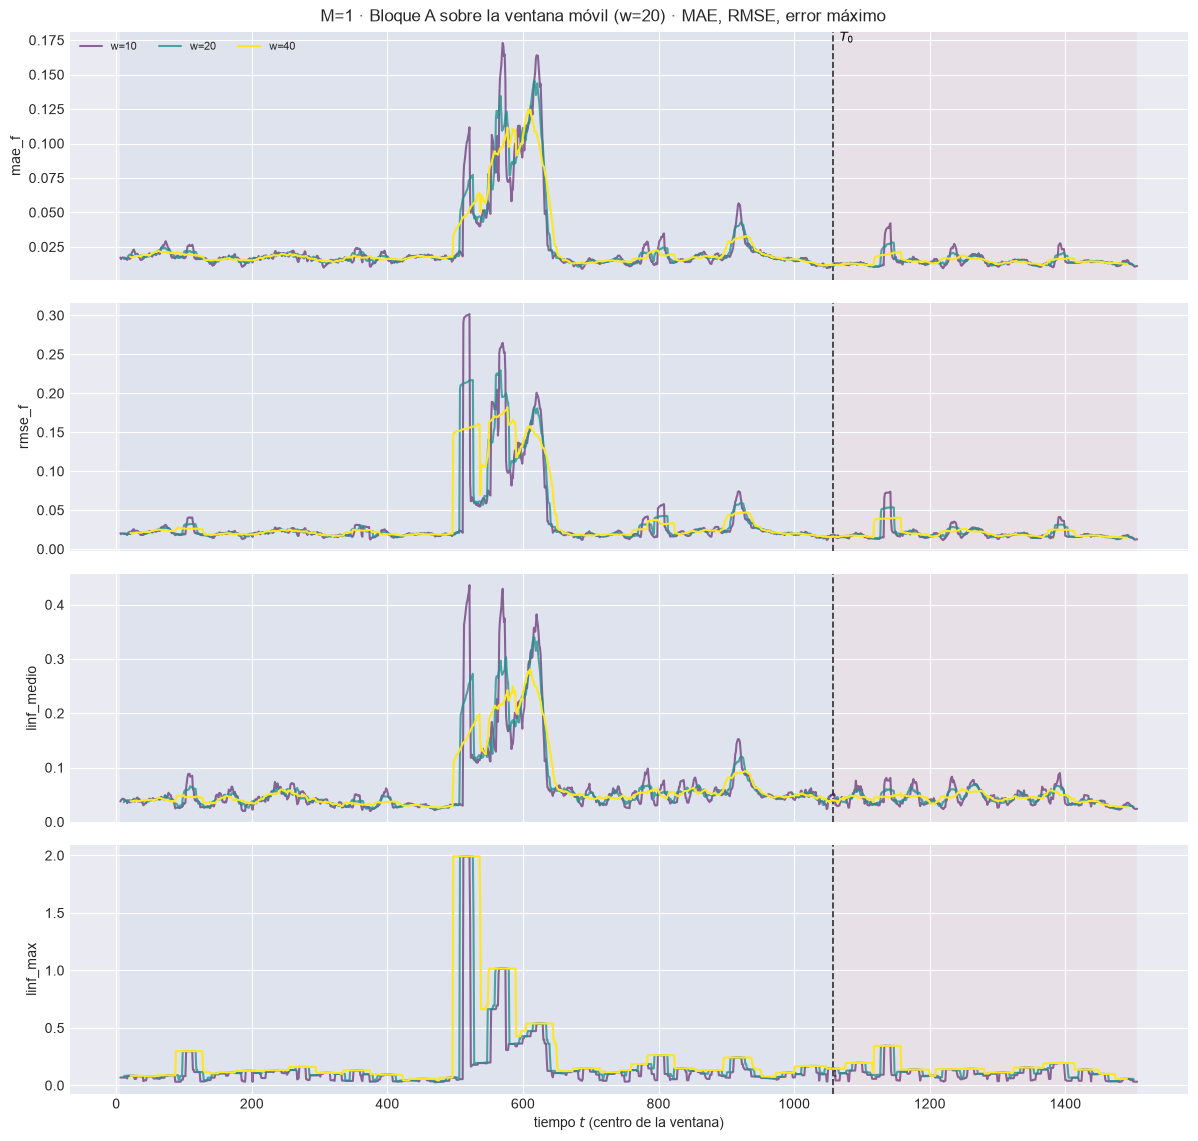

[M=1] cadena L^1 <= L^2 <= L^inf verificada en las 1491 ventanas de w=20
[plot_ventana_movil] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.1s  mae_f: w=10 train=0.01729  w=10 test=0.01216  w=20 train=0.01751  w=20 test=0.01248  w=40 train=0.01799  w=40 test=0.01304
  2/4 (50.0%) t=0.1s eta=0.1s  rmse_f: w=10 train=0.02065  w=10 test=0.01665  w=20 train=0.02093  w=20 test=0.01726  w=40 train=0.02172  w=40 test=0.0177
  3/4 (75.0%) t=0.1s eta=0.0s  linf_medio: w=10 train=0.04498  w=10 test=0.04074  w=20 train=0.04562  w=20 test=0.04193  w=40 train=0.04657  w=40 test=0.04533
  4/4 (100.0%) t=0.1s eta=0.0s  linf_max: w=10 train=0.09983  w=10 test=0.09723  w=20 train=0.1132  w=20 test=0.121  w=40 train=0.1339  w=40 test=0.1401
[plot_ventana_movil] listo: 4 pasos en 1.2s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v04_m02\60_ventana_bloqueA.png


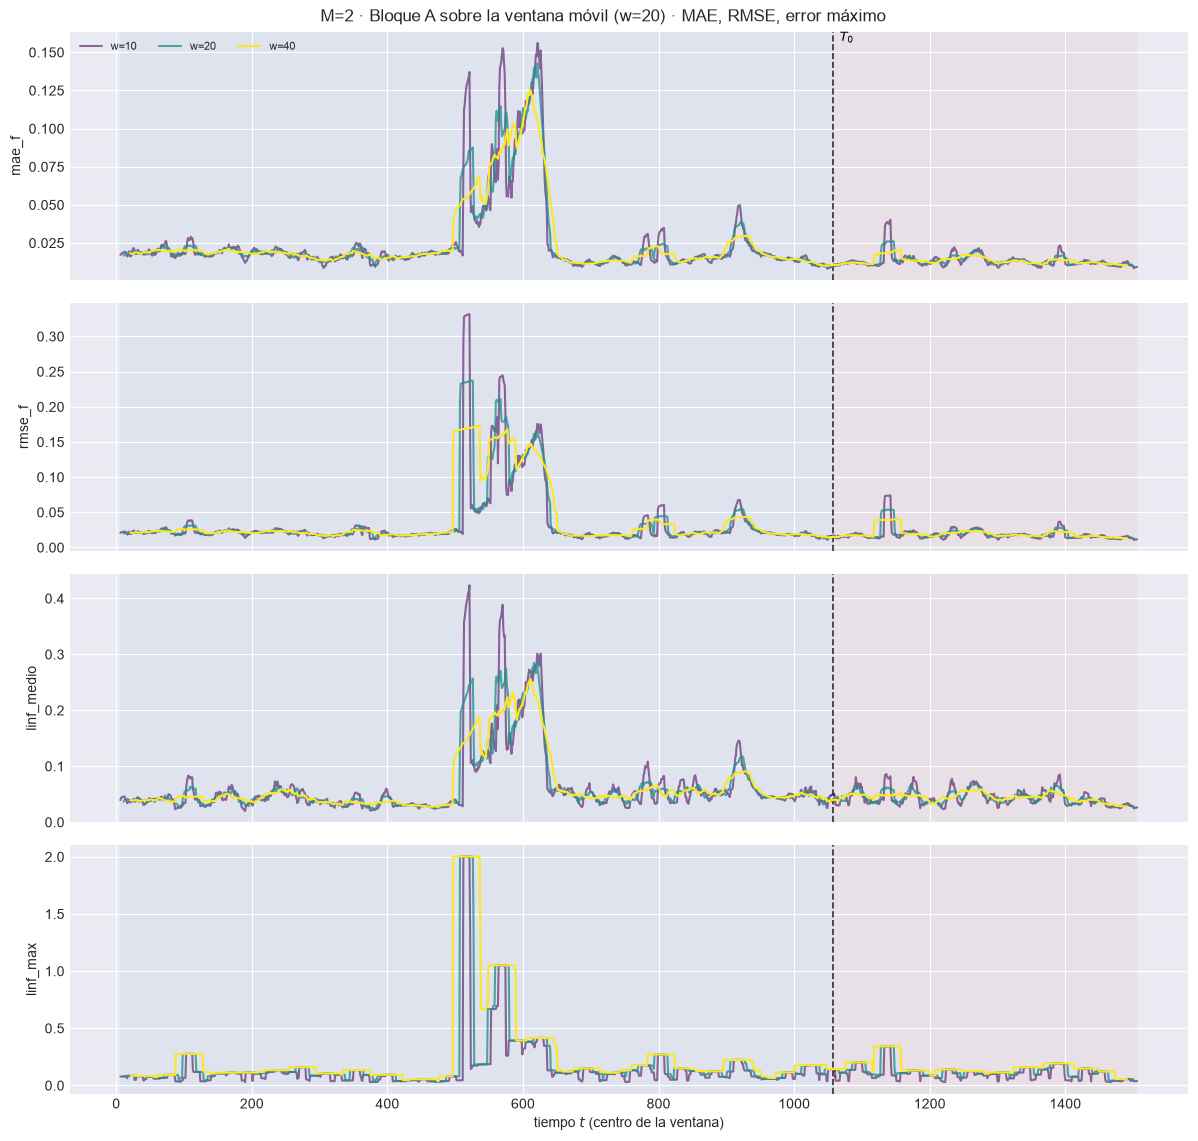

[M=2] cadena L^1 <= L^2 <= L^inf verificada en las 1491 ventanas de w=20
[plot_ventana_movil] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.1s  mae_f: w=10 train=0.01334  w=10 test=0.008712  w=20 train=0.01378  w=20 test=0.00939  w=40 train=0.01388  w=40 test=0.0101
  2/4 (50.0%) t=0.0s eta=0.0s  rmse_f: w=10 train=0.01708  w=10 test=0.01278  w=20 train=0.01782  w=20 test=0.01445  w=40 train=0.01862  w=40 test=0.01532
  3/4 (75.0%) t=0.1s eta=0.0s  linf_medio: w=10 train=0.04024  w=10 test=0.03147  w=20 train=0.04024  w=20 test=0.03512  w=40 train=0.04063  w=40 test=0.03879
  4/4 (100.0%) t=0.1s eta=0.0s  linf_max: w=10 train=0.09518  w=10 test=0.09277  w=20 train=0.111  w=20 test=0.1097  w=40 train=0.1268  w=40 test=0.133
[plot_ventana_movil] listo: 4 pasos en 0.9s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v04_m03\60_ventana_bloqueA.png


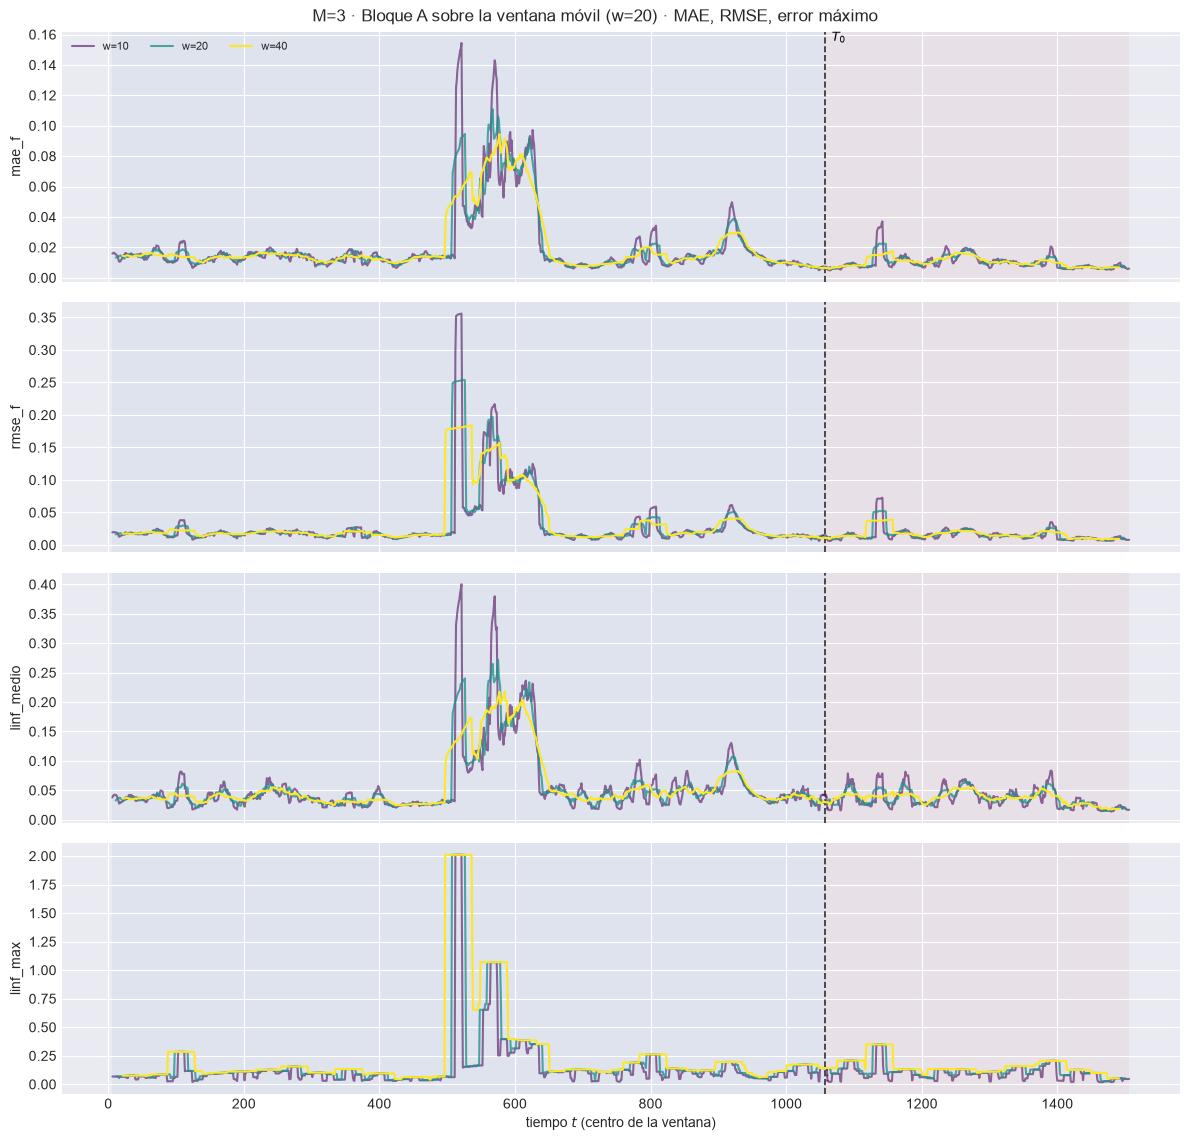

[M=3] cadena L^1 <= L^2 <= L^inf verificada en las 1491 ventanas de w=20


In [12]:
# Bloque A, una sola vista: MAE, RMSE, Error máximo, ninguno "primario".
for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]
    faltan = [c for c in METRICAS_A_COLS if c not in tfun.columns]
    assert not faltan, f"[M={M}] faltan columnas del Bloque A: {faltan}"

    plot_ventana_movil(
        tfun, T0, METRICAS_A_COLS, tablas_por_w=e["tablas_fun"],
        title=f"M={M} · Bloque A sobre la ventana móvil (w={W_REF}) · "
              "MAE, RMSE, error máximo",
        save_path=str(e["paths"]["out_report"] / "60_ventana_bloqueA.png"),
        verbose=True)
    plt.show()

    # La cadena va sobre l2_medio, no sobre rmse_f: rmse_f es media CUADRATICA
    # entre origenes y puede superar a linf_medio si el error es desigual.
    assert (tfun["mae_f"] <= tfun["l2_medio"] + 1e-9).all(), (
        f"[M={M}] mae_f > l2_medio en alguna ventana: revisar la cuadratura.")
    assert (tfun["l2_medio"] <= tfun["linf_medio"] + 1e-9).all()
    assert (tfun["linf_medio"] <= tfun["linf_max"] + 1e-9).all()
    print(f"[M={M}] cadena L^1 <= L^2 <= L^inf verificada en las "
          f"{len(tfun)} ventanas de w={W_REF}")


### 4.1 ¿Qué $M$ gana en cada ventana?

Alineando las ventanas de todos los $M$ por su $t$ central -el diseño es común
entre puntos del barrido, así que las ventanas coinciden posición a posición-,
para cada ventana y cada métrica se marca cuál $M$ dio el valor MÁS BAJO. El
panel de abajo es el porcentaje de ventanas ganadas por cada $M$, separado por
bloque train/test. Se excluyen las ventanas que cruzan $T_0$.

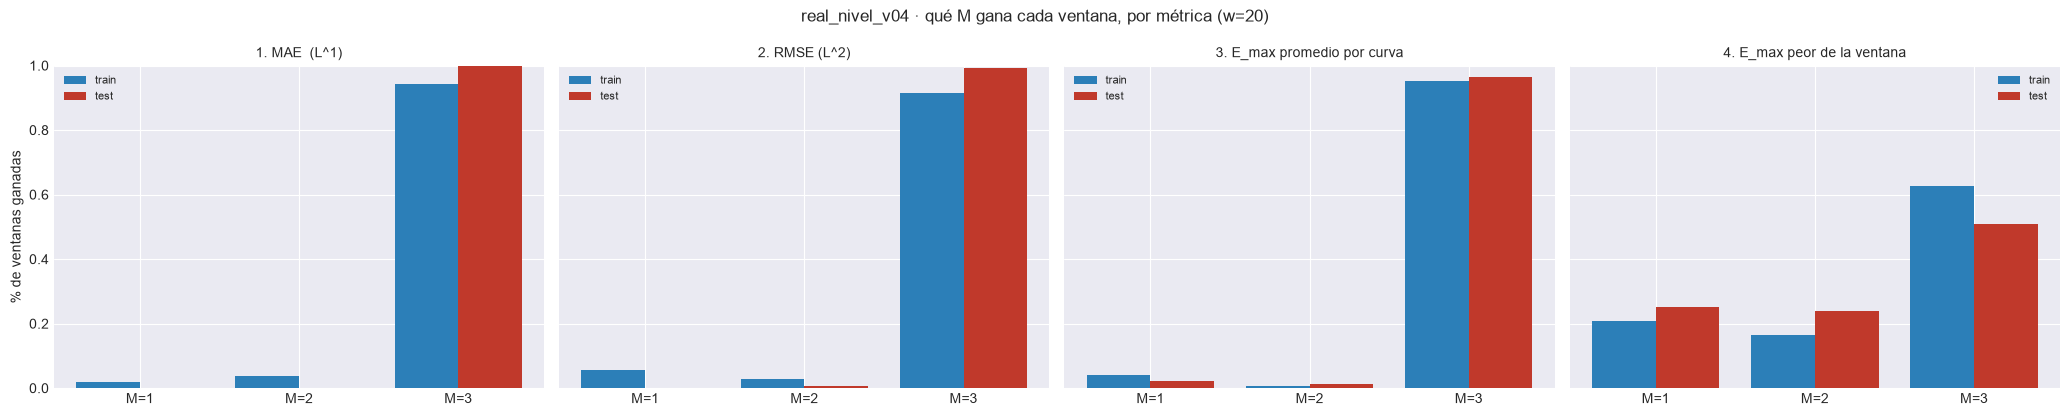

In [13]:

tablas_M = {M: EST[M]["tablas_fun"][W_REF] for M in M_OK}
_ref = tablas_M[M_OK[0]]
for M in M_OK[1:]:
    assert list(tablas_M[M]["t_centro"]) == list(_ref["t_centro"]), (
        f"[M={M}] las ventanas no estan alineadas con M={M_OK[0]}: revisar "
        "que T, T0, n_lags y VENTANAS_W sean comunes (ya se verifico en §1, "
        "pero aqui es donde importaria).")

ganancias = []
for etiqueta, col in METRICAS_A:
    valores = pd.DataFrame({M: tablas_M[M][col].to_numpy() for M in M_OK})
    ganador = valores.idxmin(axis=1)          # el M con el valor MAS BAJO
    tabla_g = pd.DataFrame({
        "t_centro": _ref["t_centro"], "bloque": _ref["bloque"],
        "cruza_T0": _ref["cruza_T0"], "ganador": ganador})
    limpio_g = tabla_g[~tabla_g["cruza_T0"]]
    for bloque in ("train", "test"):
        sub = limpio_g[limpio_g.bloque == bloque]
        n_tot = len(sub)
        for M in M_OK:
            pct = float((sub["ganador"] == M).mean()) if n_tot else float("nan")
            ganancias.append({"metrica": etiqueta, "bloque": bloque, "M": M,
                              "pct_ventanas_ganadas": pct, "n_ventanas": n_tot})

gana_df = pd.DataFrame(ganancias)
gana_df.to_csv(PATH_BARRIDO / "84_ganador_por_ventana.csv", index=False)

fig, axes = plt.subplots(1, len(METRICAS_A), figsize=(5.2 * len(METRICAS_A), 4.2),
                         sharey=True)
if len(METRICAS_A) == 1:
    axes = [axes]
ancho_barra = 0.8 / 2
for ax, (etiqueta, _) in zip(axes, METRICAS_A):
    sub = gana_df[gana_df.metrica == etiqueta]
    xs = np.arange(len(M_OK))
    for i_b, bloque in enumerate(("train", "test")):
        vals = [float(sub[(sub.M == M) & (sub.bloque == bloque)]
                     ["pct_ventanas_ganadas"].iloc[0]) for M in M_OK]
        ax.bar(xs + (i_b - 0.5) * ancho_barra, vals, width=ancho_barra,
              label=bloque, color=("#2c7fb8" if bloque == "train" else "#c0392b"))
    ax.set_xticks(xs); ax.set_xticklabels([f"M={M}" for M in M_OK])
    ax.set_title(etiqueta, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
axes[0].set_ylabel("% de ventanas ganadas")
fig.suptitle(f"{EXPERIMENT_BASE} · qué M gana cada ventana, por métrica "
             f"(w={W_REF})", fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "84_ganador_por_ventana.png", dpi=150, bbox_inches="tight")
plt.show()

display(gana_df.pivot_table(index=["metrica", "bloque"], columns="M",
                            values="pct_ventanas_ganadas")
        .style.format("{:.1%}")
        .set_caption("% de ventanas ganadas por M, por métrica y bloque "
                     "(84_ganador_por_ventana.csv)"))


In [14]:
# Lectura numérica del salto en T0, excluyendo las ventanas que lo cruzan.
for M in M_OK:
    e = EST[M]
    print(f"── M={M} ──")
    print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}")
    print(f"{'-'*4}  {'-'*11}  {'-'*11}  {'-'*7}")
    saltos = {}
    for w in VENTANAS_W:
        t_ = e["tablas_fun"][w]
        limpio = t_[~t_["cruza_T0"]]
        a = limpio.loc[limpio.bloque == "train", "mise"].mean()
        b = limpio.loc[limpio.bloque == "test",  "mise"].mean()
        saltos[w] = float(b / a)
        print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}x")
    e["saltos_T0"] = saltos

── M=1 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     0.003576     0.000477    0.13x
  20     0.003607     0.000484    0.13x
  40     0.003672     0.000495    0.13x
── M=2 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     0.003434     0.000442    0.13x
  20     0.003464     0.000448    0.13x
  40     0.003525     0.000458    0.13x
── M=3 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     0.002968     0.000342    0.12x
  20     0.002995     0.000348    0.12x
  40     0.003049     0.000359    0.12x


## 5. Bloque B: intervalos de predicción, en una sola vista

Cuatro cifras del intervalo, ninguna "primaria" en esta vista -el Winkler es
la única regla de puntuación propia y por eso es la que ordena modelos cuando
hace falta ordenar, pero aquí se muestran las cuatro juntas-:

| | qué es | de qué es |
|---|---|---|
| **Winkler** | interval score | penaliza ancho Y cobertura a la vez |
| **Cobertura simultánea** | de $w$ curvas, cuántas quedan COMPLETAS dentro de su banda (1/0 por curva) | fracción de CURVAS |
| **Cobertura puntual (PICP)** | de una curva, qué fracción de $\tau$ cae dentro | promedio de esa fracción sobre la ventana |
| **MPIW** | ancho medio de la banda | — |

La cobertura simultánea es SIEMPRE $\le$ la puntual: basta un $\tau$ fuera
para que la curva entera cuente como no cubierta.

[plot_ventana_movil] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.2s  mpiw: w=10 train=0.2897  w=10 test=0.2367  w=20 train=0.2956  w=20 test=0.2367  w=40 train=0.2985  w=40 test=0.2349
  2/6 (33.3%) t=0.1s eta=0.1s  picp: w=10 train=0.998  w=10 test=1  w=20 train=0.9969  w=20 test=0.998  w=40 train=0.9964  w=40 test=0.998
  3/6 (50.0%) t=0.1s eta=0.1s  picp_simultaneo: w=10 train=0.9  w=10 test=1  w=20 train=0.9  w=20 test=0.95  w=40 train=0.9  w=40 test=0.925
  4/6 (66.7%) t=0.1s eta=0.1s  winkler: w=10 train=0.3113  w=10 test=0.239  w=20 train=0.3202  w=20 test=0.2397  w=40 train=0.3152  w=40 test=0.2387
  5/6 (83.3%) t=0.1s eta=0.0s  winkler_max_medio: w=10 train=0.4732  w=10 test=0.3482  w=20 train=0.4871  w=20 test=0.3881  w=40 train=0.4901  w=40 test=0.4075
  6/6 (100.0%) t=0.2s eta=0.0s  winkler_max_glob: w=10 train=0.822  w=10 test=0.4299  w=20 train=1.511  w=20 test=1.561  w=40 train=2.409  w=40 test=2.359
[plot_ventana_movil] listo: 6 pasos en 1.7s  -> C:\Users\56jua\Desktop\

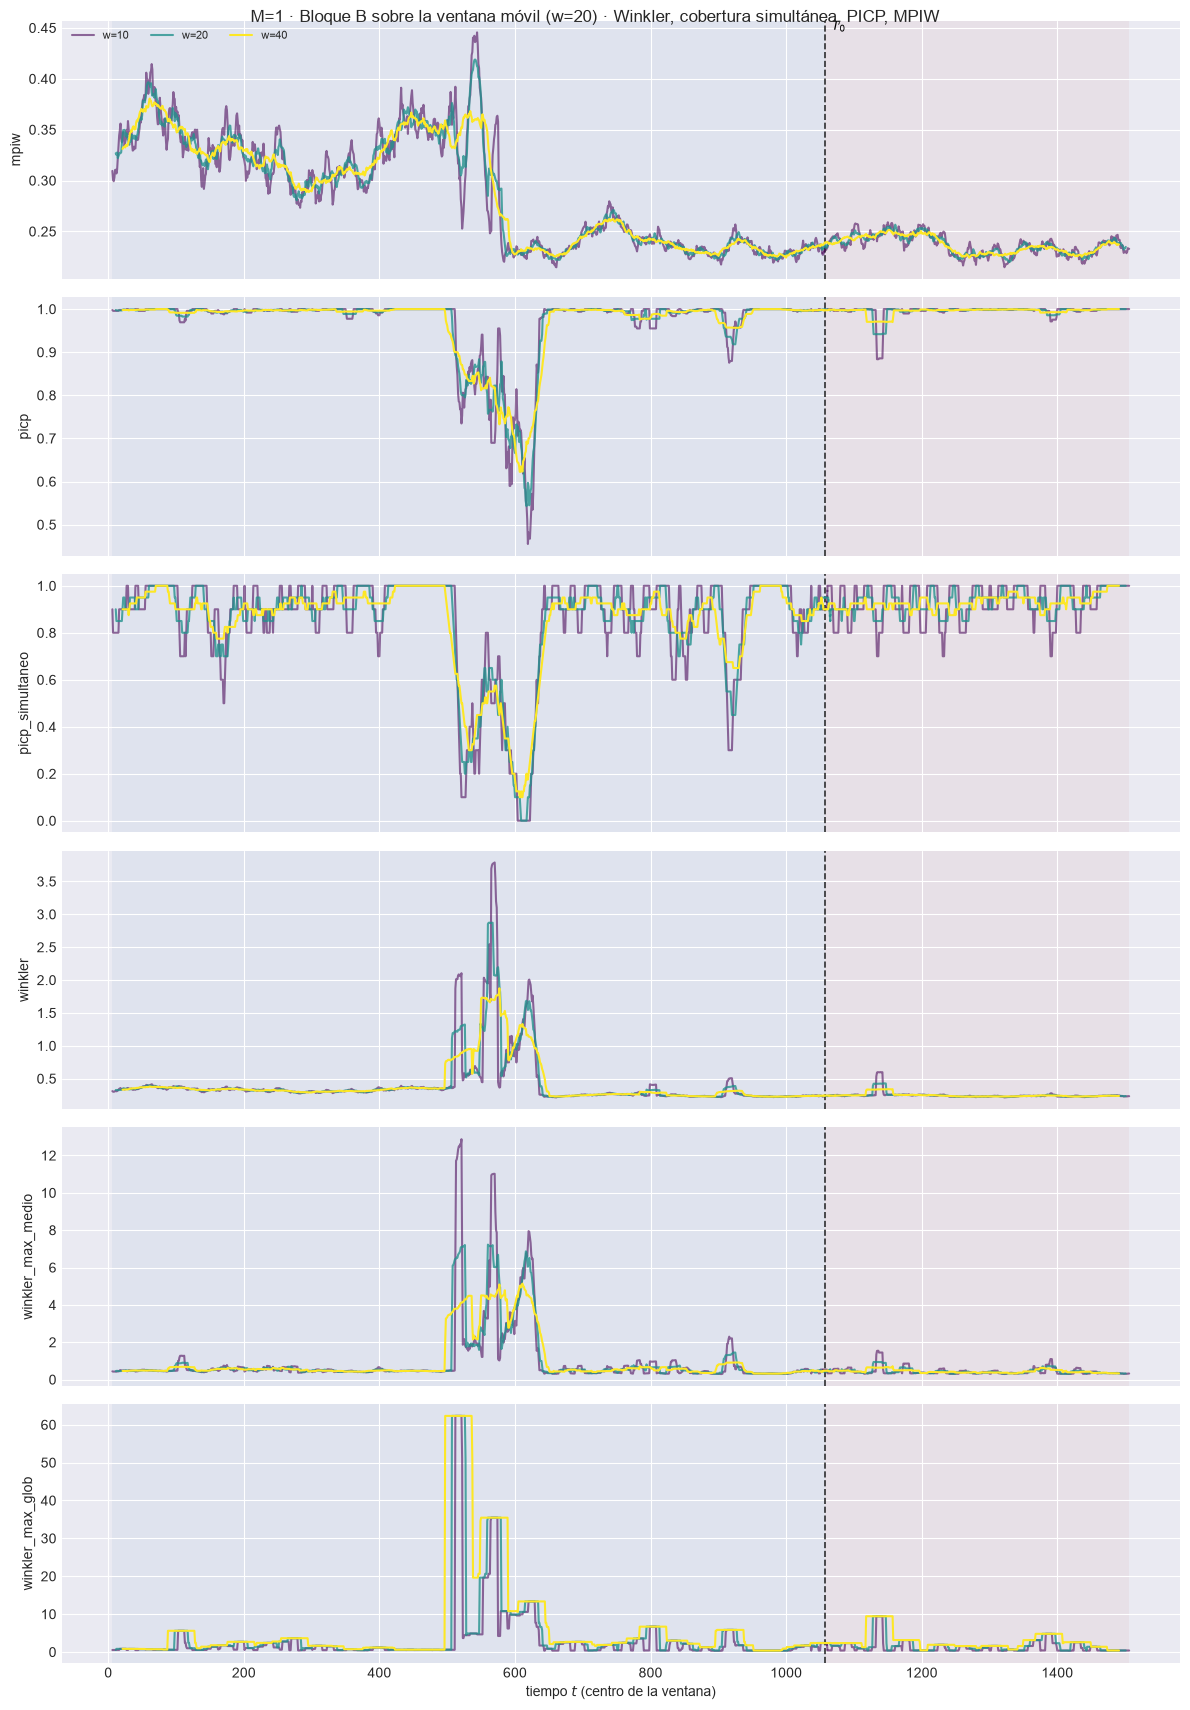

[plot_ventana_movil] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.1s  mpiw: w=10 train=0.3004  w=10 test=0.2301  w=20 train=0.306  w=20 test=0.2285  w=40 train=0.3082  w=40 test=0.2275
  2/6 (33.3%) t=0.0s eta=0.1s  picp: w=10 train=0.998  w=10 test=1  w=20 train=0.998  w=20 test=0.999  w=40 train=0.9969  w=40 test=0.9985
  3/6 (50.0%) t=0.1s eta=0.1s  picp_simultaneo: w=10 train=0.9  w=10 test=1  w=20 train=0.95  w=20 test=0.95  w=40 train=0.925  w=40 test=0.925
  4/6 (66.7%) t=0.1s eta=0.0s  winkler: w=10 train=0.3161  w=10 test=0.2305  w=20 train=0.326  w=20 test=0.2299  w=40 train=0.3245  w=40 test=0.2296
  5/6 (83.3%) t=0.1s eta=0.0s  winkler_max_medio: w=10 train=0.4413  w=10 test=0.3143  w=20 train=0.4603  w=20 test=0.3513  w=40 train=0.4576  w=40 test=0.3641
  6/6 (100.0%) t=0.1s eta=0.0s  winkler_max_glob: w=10 train=0.5873  w=10 test=0.3608  w=20 train=1.166  w=20 test=1.165  w=40 train=1.899  w=40 test=2.188
[plot_ventana_movil] listo: 6 pasos en 1.1s  -> C:\Users\56jua\Deskt

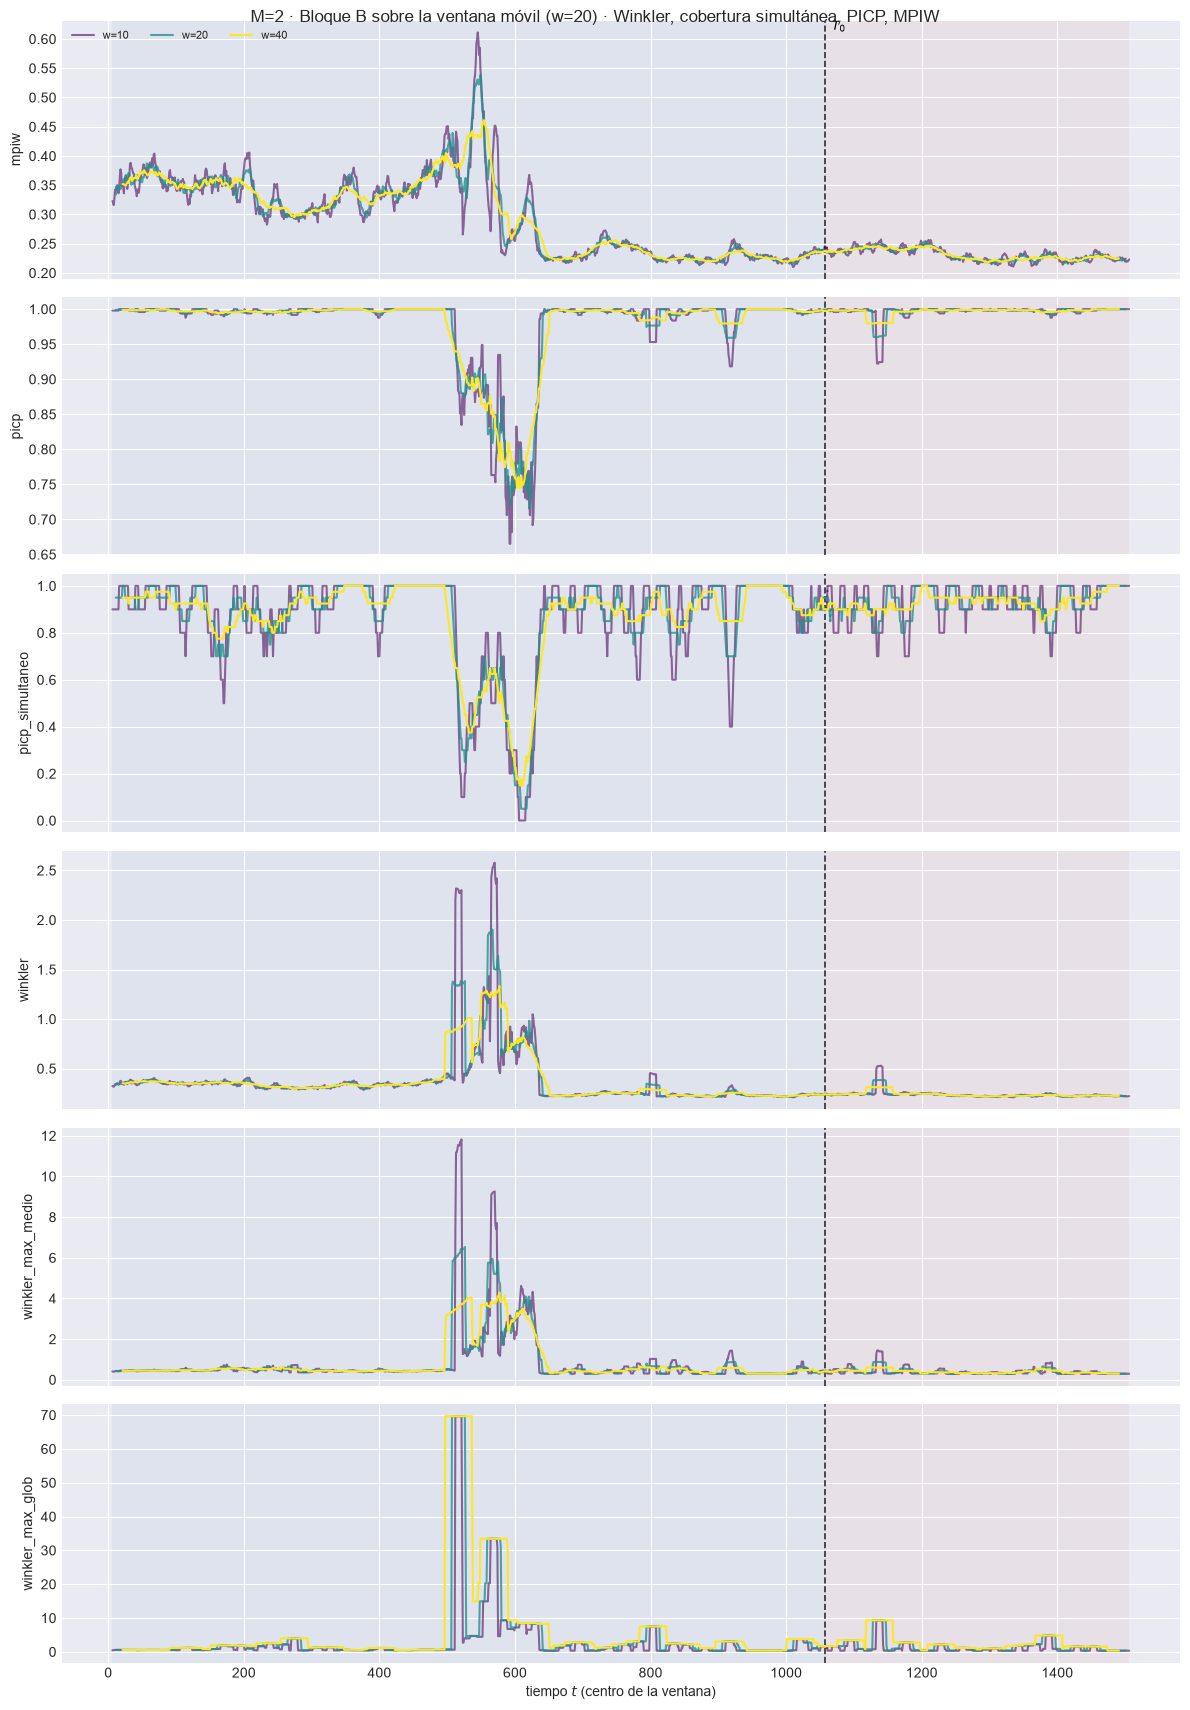

[plot_ventana_movil] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.1s  mpiw: w=10 train=0.2287  w=10 test=0.1824  w=20 train=0.2324  w=20 test=0.1827  w=40 train=0.2358  w=40 test=0.1828
  2/6 (33.3%) t=0.0s eta=0.1s  picp: w=10 train=0.998  w=10 test=0.998  w=20 train=0.9959  w=20 test=0.998  w=40 train=0.9959  w=40 test=0.9964
  3/6 (50.0%) t=0.1s eta=0.1s  picp_simultaneo: w=10 train=0.9  w=10 test=0.9  w=20 train=0.9  w=20 test=0.9  w=40 train=0.875  w=40 test=0.9
  4/6 (66.7%) t=0.1s eta=0.0s  winkler: w=10 train=0.2379  w=10 test=0.1837  w=20 train=0.2409  w=20 test=0.1848  w=40 train=0.2477  w=40 test=0.1861
  5/6 (83.3%) t=0.1s eta=0.0s  winkler_max_medio: w=10 train=0.3692  w=10 test=0.2738  w=20 train=0.3834  w=20 test=0.3062  w=40 train=0.4006  w=40 test=0.3184
  6/6 (100.0%) t=0.1s eta=0.0s  winkler_max_glob: w=10 train=0.6771  w=10 test=0.62  w=20 train=1.484  w=20 test=1.145  w=40 train=2.132  w=40 test=2.282
[plot_ventana_movil] listo: 6 pasos en 1.4s  -> C:\Users\56jua\De

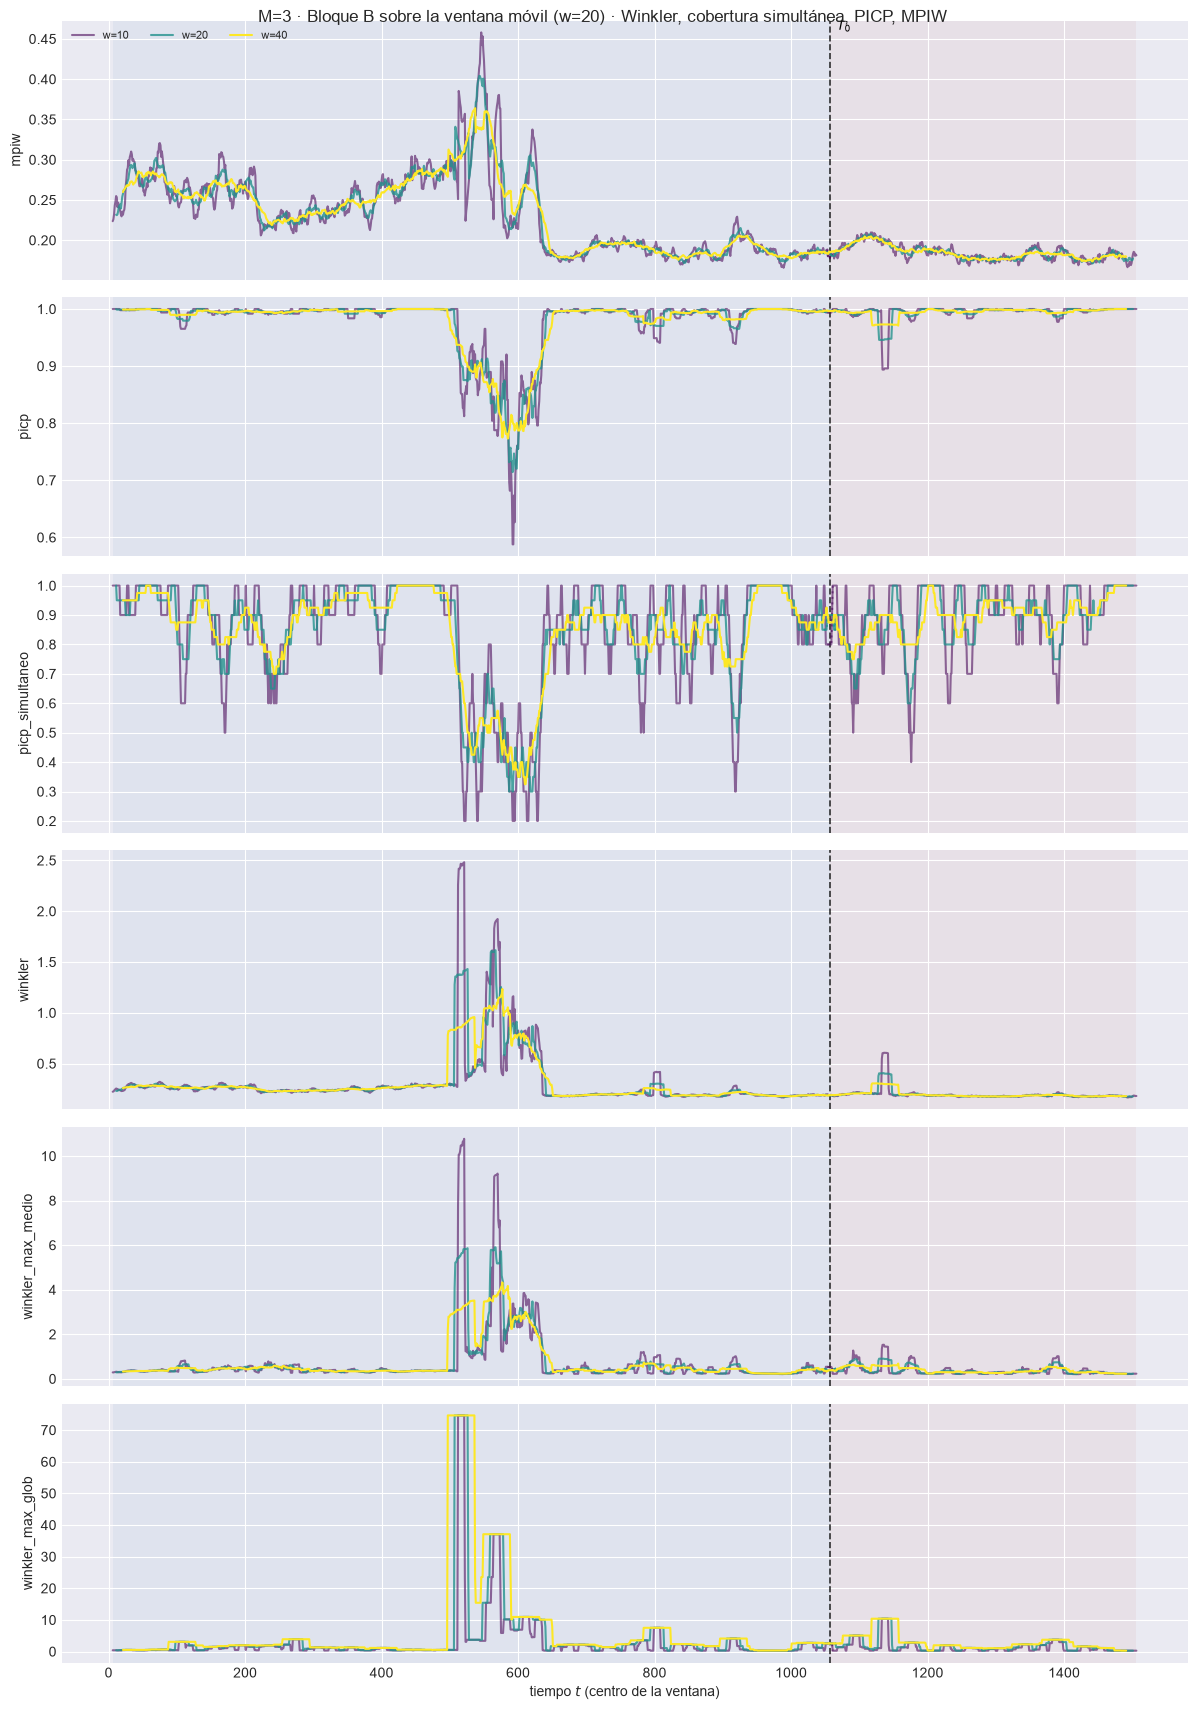

In [15]:
# Bloque B, una sola vista: Winkler, cobertura simultanea, cobertura puntual,
# MPIW. Reutiliza tablas_fun, ya calculada en §4.
for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]
    faltan = [c for c in METRICAS_B_COLS if c not in tfun.columns]
    assert not faltan, (
        f"[M={M}] faltan columnas del Bloque B: {faltan}. Revisar que "
        "ventana_movil_funcional se haya llamado con li/ls y bloque_A=True.")

    plot_ventana_movil(
        tfun, T0, METRICAS_B_COLS, tablas_por_w=e["tablas_fun"],
        title=f"M={M} · Bloque B sobre la ventana móvil (w={W_REF}) · "
              "Winkler, cobertura simultánea, PICP, MPIW",
        save_path=str(e["paths"]["out_report"] / "61_ventana_bloqueB.png"),
        verbose=True)
    plt.show()

    assert (tfun["picp_simultaneo"] <= tfun["picp"] + 1e-9).all(), (
        f"[M={M}] la cobertura simultanea supero a la puntual en alguna "
        "ventana: no puede pasar por definicion.")


## 6. Muestra de predicciones

Dos vistas: un extracto regular del bloque de **prueba** (para no mezclar con
in-sample), y las ventanas con **peor** valor de `METRICA_PEORES` ([CONFIG]).
En la segunda se agrega la curva **anterior** ($t-1$, gris punteada): es el
primer diagnóstico de POR QUÉ el modelo se equivocó -¿la curva de partida ya
era atípica?-.

[plot_extractos_curvas] inicio (16 pasos)
  1/16 ( 6.2%) t=0.0s eta=0.1s  t=1058 [test] cob=1.000 rmse=0.01591
  2/16 (12.5%) t=0.0s eta=0.1s  t=1088 [test] cob=1.000 rmse=0.02878
  3/16 (18.8%) t=0.0s eta=0.1s  t=1118 [test] cob=1.000 rmse=0.0137
  4/16 (25.0%) t=0.0s eta=0.1s  t=1148 [test] cob=1.000 rmse=0.01087
  5/16 (31.2%) t=0.0s eta=0.1s  t=1178 [test] cob=0.939 rmse=0.03346
  6/16 (37.5%) t=0.1s eta=0.1s  t=1208 [test] cob=1.000 rmse=0.01535
  7/16 (43.8%) t=0.1s eta=0.1s  t=1238 [test] cob=1.000 rmse=0.01721
  8/16 (50.0%) t=0.1s eta=0.1s  t=1268 [test] cob=1.000 rmse=0.03754
  9/16 (56.2%) t=0.1s eta=0.1s  t=1298 [test] cob=1.000 rmse=0.01164
  10/16 (62.5%) t=0.1s eta=0.1s  t=1328 [test] cob=1.000 rmse=0.02188
  11/16 (68.8%) t=0.1s eta=0.1s  t=1358 [test] cob=1.000 rmse=0.01851
  12/16 (75.0%) t=0.1s eta=0.0s  t=1388 [test] cob=0.959 rmse=0.03533
  13/16 (81.2%) t=0.1s eta=0.0s  t=1418 [test] cob=1.000 rmse=0.016
  14/16 (87.5%) t=0.2s eta=0.0s  t=1448 [test] cob=1.000 rms

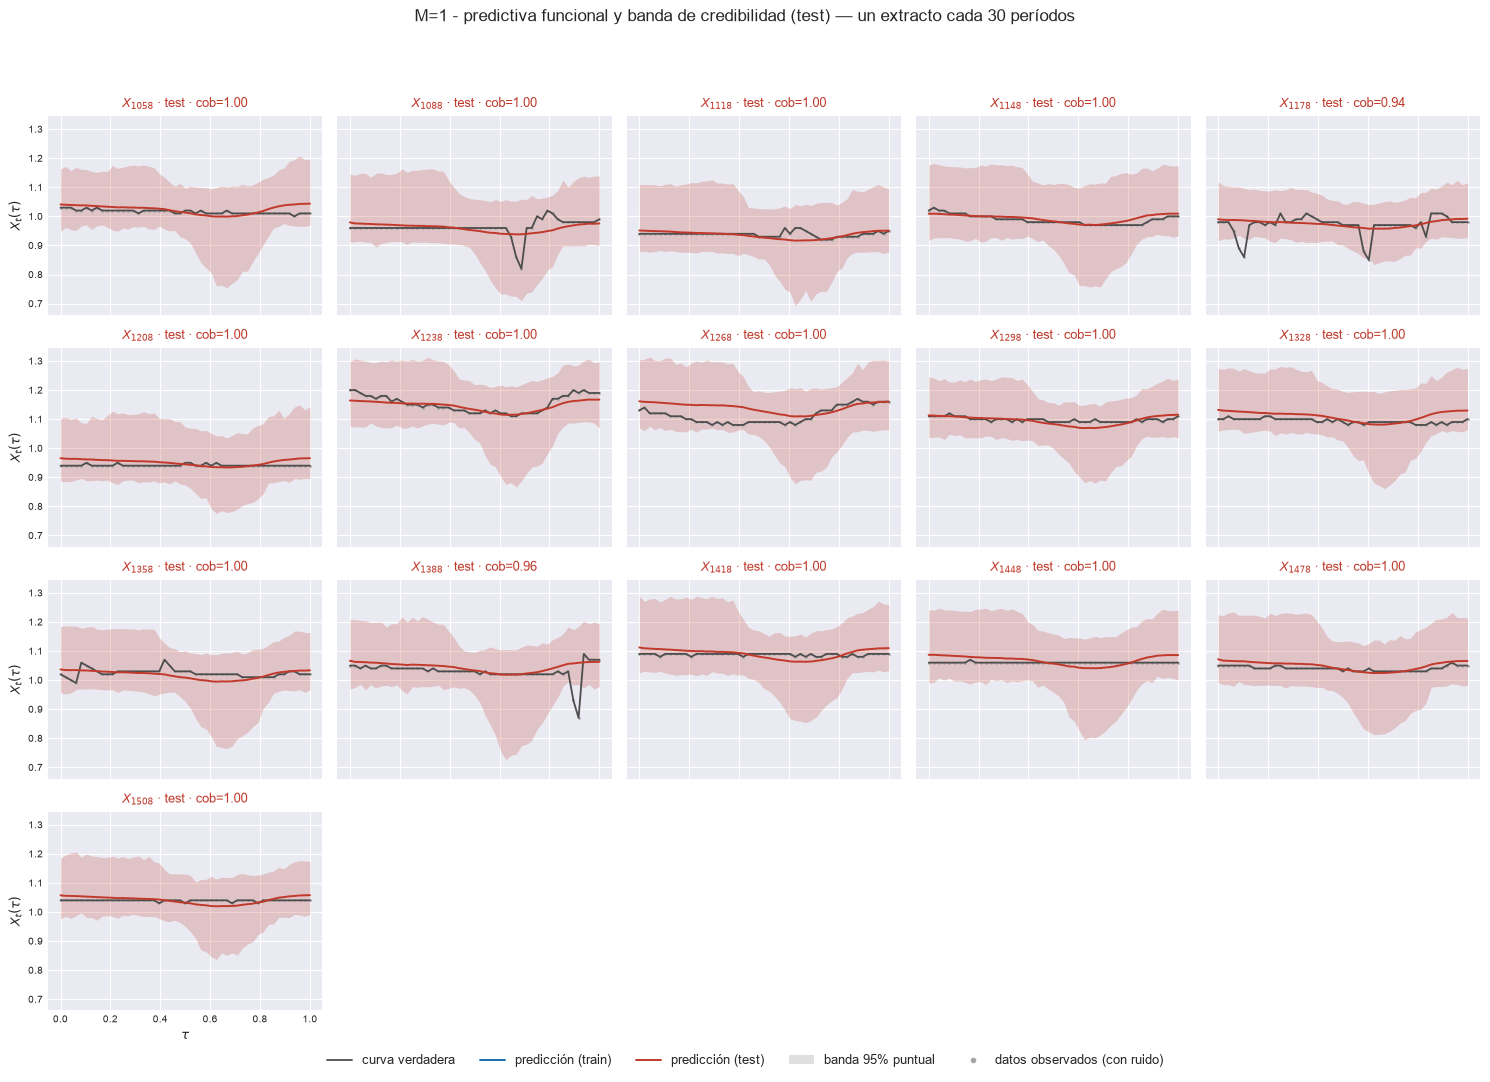

[plot_extractos_curvas] inicio (16 pasos)
  1/16 ( 6.2%) t=0.0s eta=0.1s  t=1058 [test] cob=1.000 rmse=0.01353
  2/16 (12.5%) t=0.0s eta=0.1s  t=1088 [test] cob=1.000 rmse=0.02761
  3/16 (18.8%) t=0.0s eta=0.1s  t=1118 [test] cob=1.000 rmse=0.01406
  4/16 (25.0%) t=0.0s eta=0.1s  t=1148 [test] cob=1.000 rmse=0.01321
  5/16 (31.2%) t=0.0s eta=0.1s  t=1178 [test] cob=0.939 rmse=0.03554
  6/16 (37.5%) t=0.1s eta=0.1s  t=1208 [test] cob=1.000 rmse=0.01428
  7/16 (43.8%) t=0.1s eta=0.1s  t=1238 [test] cob=1.000 rmse=0.01707
  8/16 (50.0%) t=0.1s eta=0.1s  t=1268 [test] cob=1.000 rmse=0.03511
  9/16 (56.2%) t=0.1s eta=0.1s  t=1298 [test] cob=1.000 rmse=0.01174
  10/16 (62.5%) t=0.1s eta=0.1s  t=1328 [test] cob=1.000 rmse=0.01689
  11/16 (68.8%) t=0.1s eta=0.0s  t=1358 [test] cob=1.000 rmse=0.01747
  12/16 (75.0%) t=0.1s eta=0.0s  t=1388 [test] cob=0.959 rmse=0.03619
  13/16 (81.2%) t=0.1s eta=0.0s  t=1418 [test] cob=1.000 rmse=0.01425
  14/16 (87.5%) t=0.1s eta=0.0s  t=1448 [test] cob=1.000 

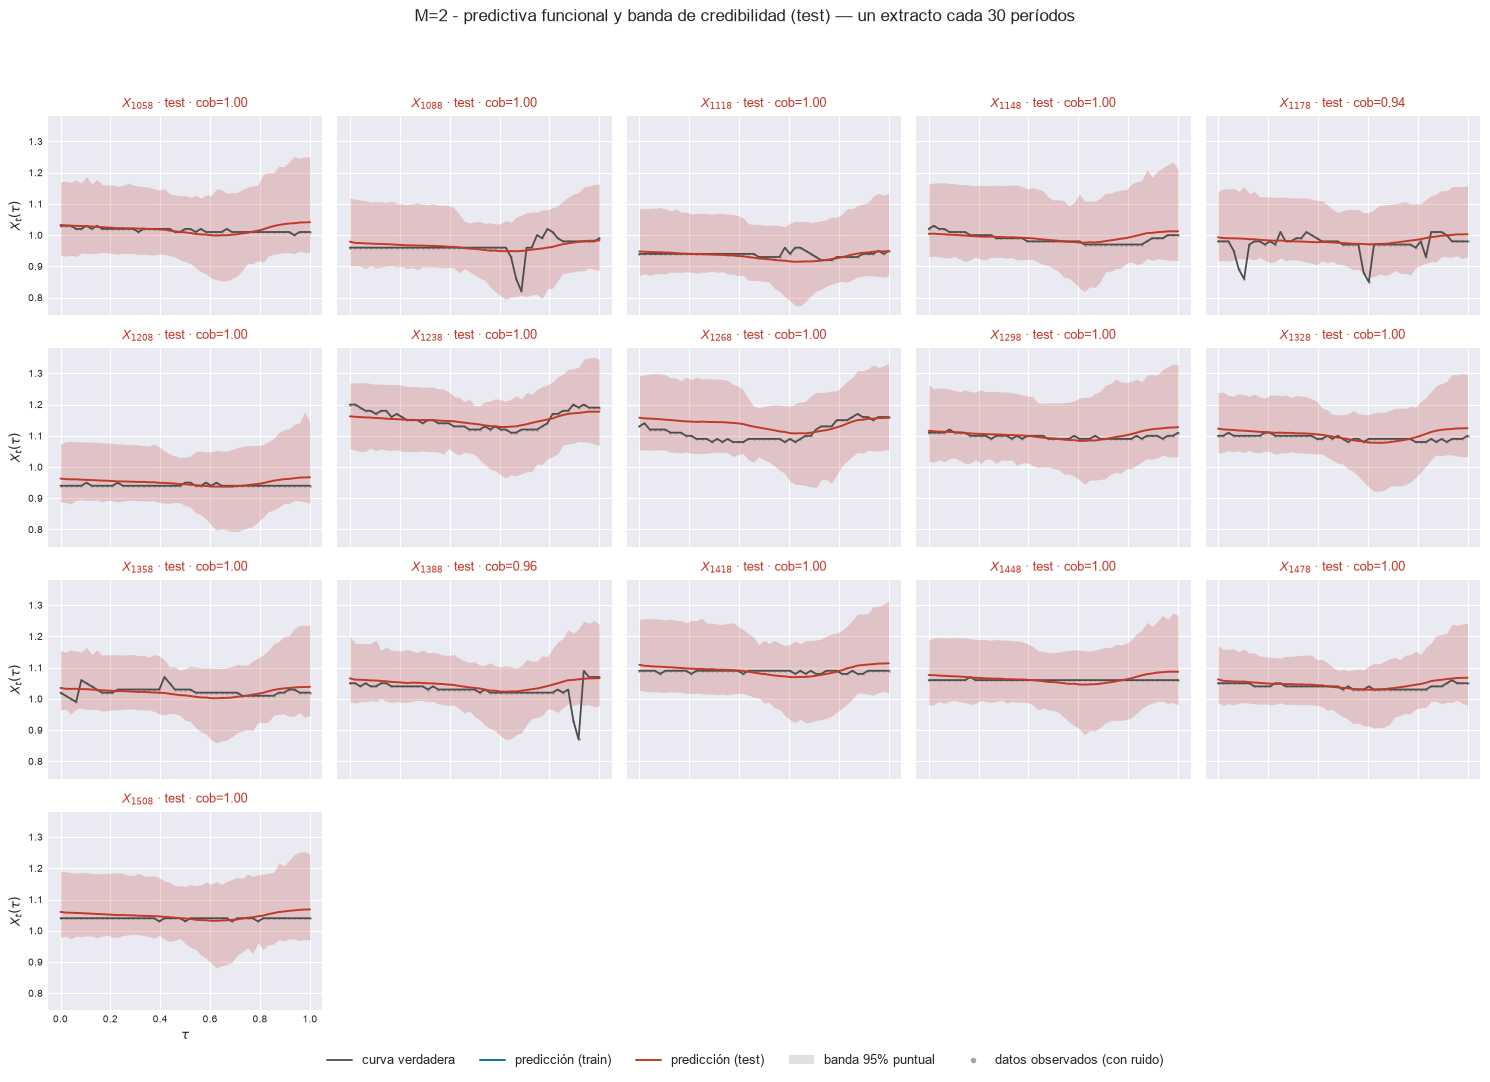

[plot_extractos_curvas] inicio (16 pasos)
  1/16 ( 6.2%) t=0.0s eta=0.1s  t=1058 [test] cob=1.000 rmse=0.00944
  2/16 (12.5%) t=0.0s eta=0.1s  t=1088 [test] cob=0.980 rmse=0.02794
  3/16 (18.8%) t=0.0s eta=0.2s  t=1118 [test] cob=1.000 rmse=0.01639
  4/16 (25.0%) t=0.1s eta=0.2s  t=1148 [test] cob=1.000 rmse=0.01432
  5/16 (31.2%) t=0.1s eta=0.1s  t=1178 [test] cob=0.918 rmse=0.03659
  6/16 (37.5%) t=0.1s eta=0.1s  t=1208 [test] cob=1.000 rmse=0.007854
  7/16 (43.8%) t=0.1s eta=0.1s  t=1238 [test] cob=1.000 rmse=0.01984
  8/16 (50.0%) t=0.1s eta=0.1s  t=1268 [test] cob=1.000 rmse=0.0352
  9/16 (56.2%) t=0.1s eta=0.1s  t=1298 [test] cob=1.000 rmse=0.008358
  10/16 (62.5%) t=0.1s eta=0.1s  t=1328 [test] cob=1.000 rmse=0.01348
  11/16 (68.8%) t=0.1s eta=0.1s  t=1358 [test] cob=1.000 rmse=0.01555
  12/16 (75.0%) t=0.1s eta=0.0s  t=1388 [test] cob=0.959 rmse=0.03329
  13/16 (81.2%) t=0.1s eta=0.0s  t=1418 [test] cob=1.000 rmse=0.00684
  14/16 (87.5%) t=0.1s eta=0.0s  t=1448 [test] cob=1.000

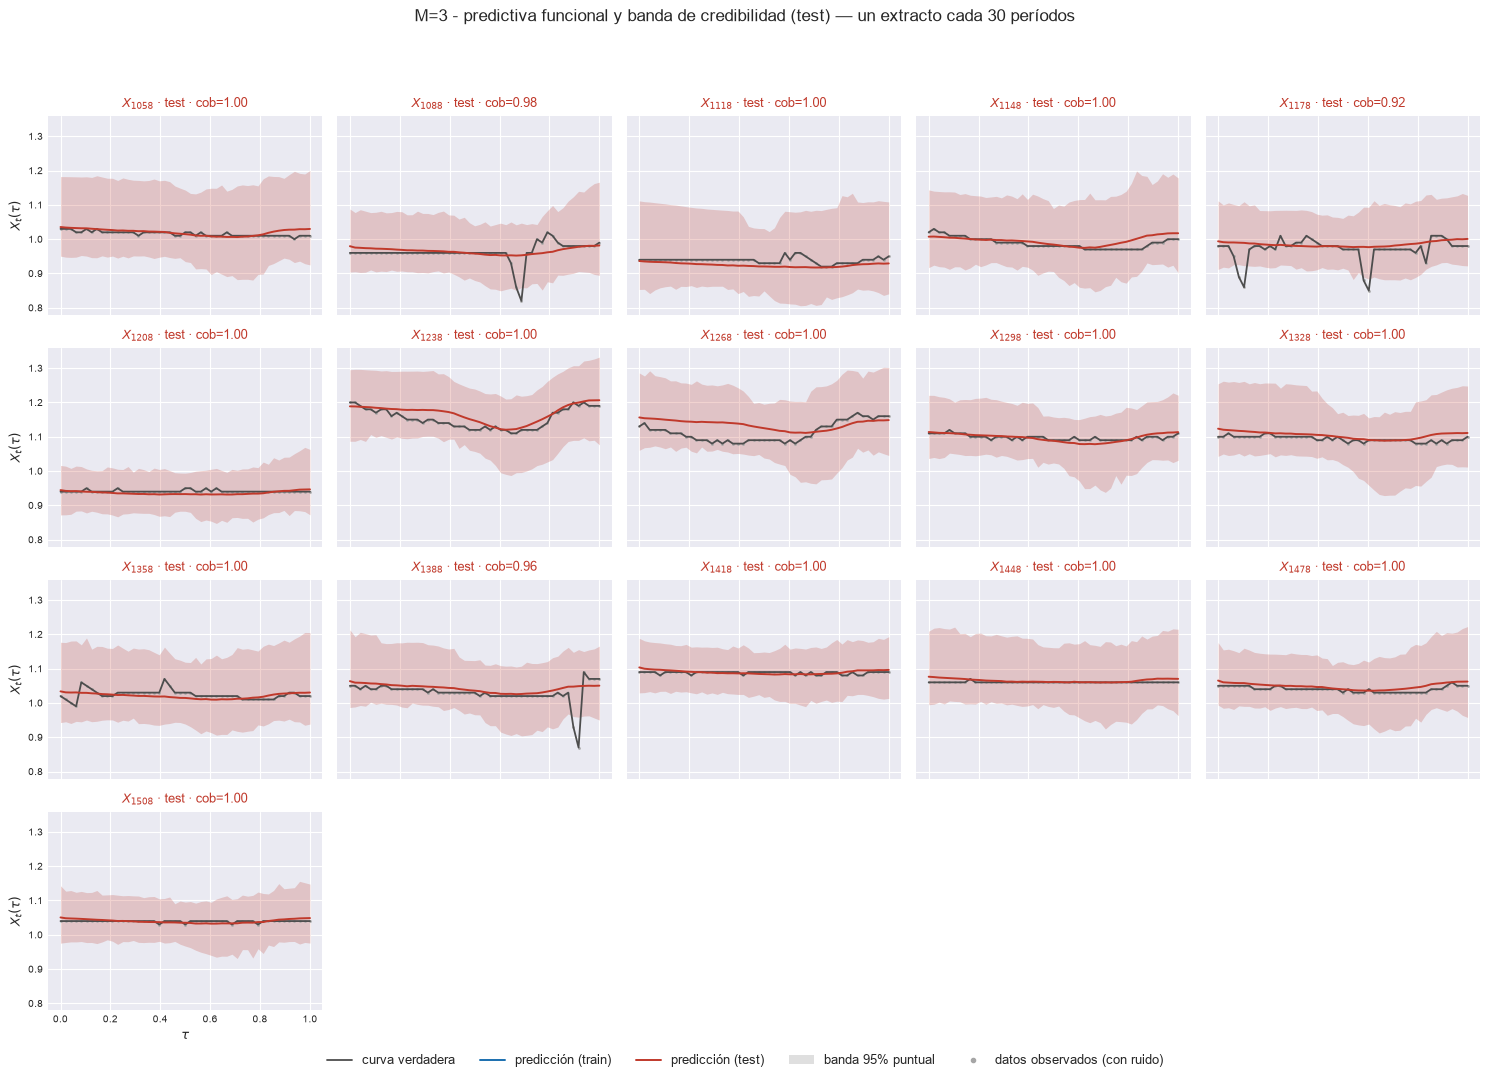

In [16]:
# Extractos regulares, SOLO del bloque de prueba.
mask_test = ~es_train
for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_true_ev[mask_test], e["X_pred"][mask_test], e["li_f"][mask_test],
        e["ls_f"][mask_test], grilla, T0, t=t_orig[mask_test],
        cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev[mask_test],
        title=f"M={M} - predictiva funcional y banda de credibilidad (test)",
        save_path=str(e["paths"]["out_report"] / "54_extractos_curvas_test.png"),
        verbose=True)
    plt.show()


[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=1054 [train] cob=1.000 rmse=0.01521
  2/7 (28.6%) t=0.0s eta=0.0s  t=1055 [train] cob=1.000 rmse=0.02387
  3/7 (42.9%) t=0.0s eta=0.0s  t=1056 [train] cob=0.980 rmse=0.03486
  4/7 (57.1%) t=0.0s eta=0.0s  t=1057 [train] cob=1.000 rmse=0.01014
  5/7 (71.4%) t=0.0s eta=0.0s  t=1058 [test] cob=1.000 rmse=0.01591
  6/7 (85.7%) t=0.0s eta=0.0s  t=1059 [test] cob=1.000 rmse=0.01928
  7/7 (100.0%) t=0.0s eta=0.0s  t=1060 [test] cob=1.000 rmse=0.01161
[plot_extractos_curvas] listo: 7 pasos en 1.3s  cob media train=0.995 test=1.000 (nominal 0.95)


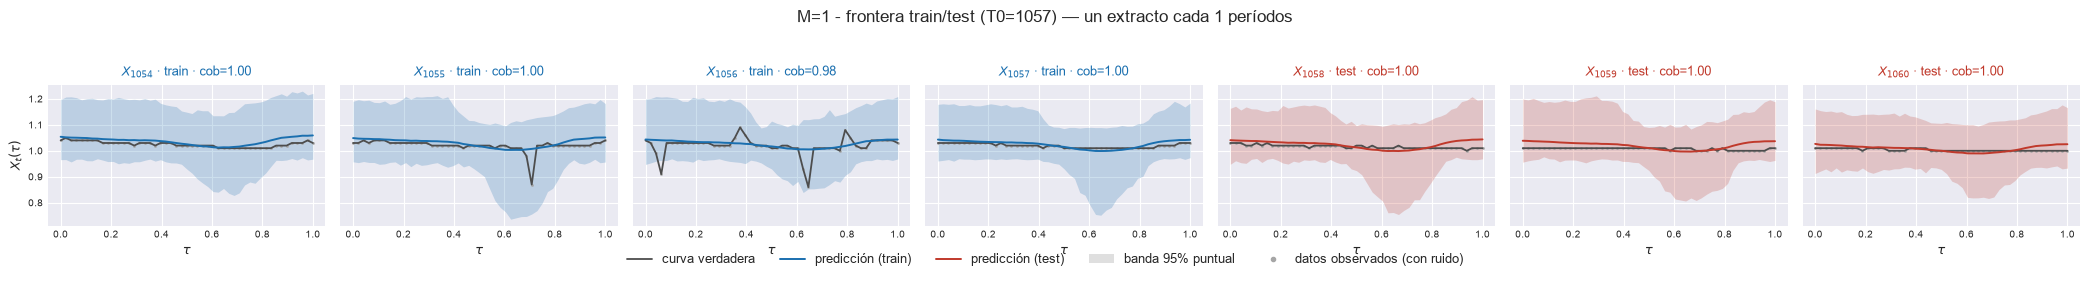

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=1054 [train] cob=1.000 rmse=0.01009
  2/7 (28.6%) t=0.0s eta=0.0s  t=1055 [train] cob=1.000 rmse=0.02183
  3/7 (42.9%) t=0.0s eta=0.0s  t=1056 [train] cob=0.980 rmse=0.03435
  4/7 (57.1%) t=0.0s eta=0.0s  t=1057 [train] cob=1.000 rmse=0.01193
  5/7 (71.4%) t=0.0s eta=0.0s  t=1058 [test] cob=1.000 rmse=0.01353
  6/7 (85.7%) t=0.0s eta=0.0s  t=1059 [test] cob=1.000 rmse=0.01437
  7/7 (100.0%) t=0.0s eta=0.0s  t=1060 [test] cob=1.000 rmse=0.01213
[plot_extractos_curvas] listo: 7 pasos en 0.8s  cob media train=0.995 test=1.000 (nominal 0.95)


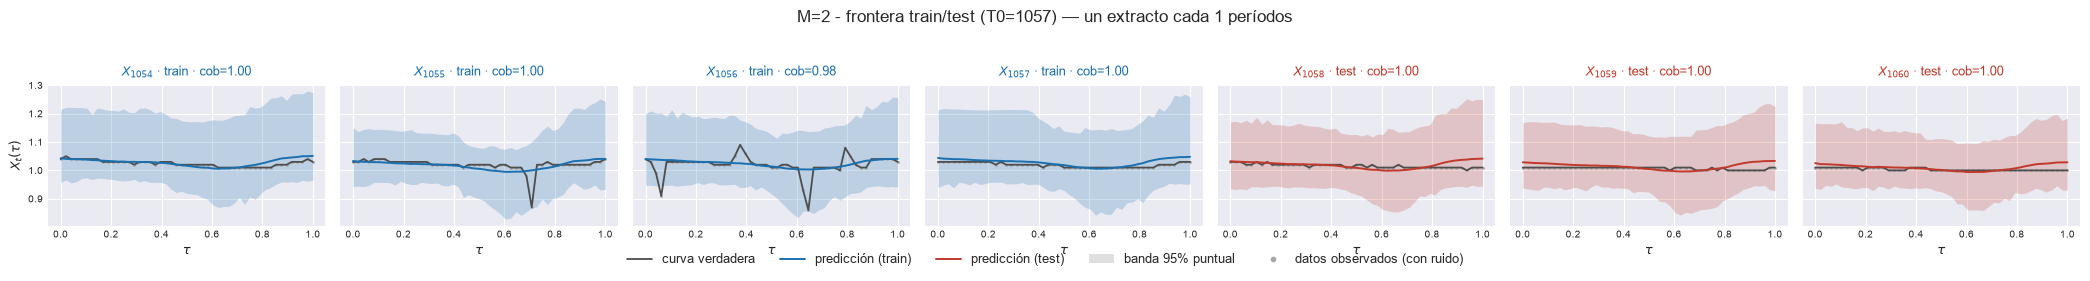

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=1054 [train] cob=1.000 rmse=0.007116
  2/7 (28.6%) t=0.0s eta=0.0s  t=1055 [train] cob=0.980 rmse=0.02152
  3/7 (42.9%) t=0.0s eta=0.0s  t=1056 [train] cob=0.959 rmse=0.03452
  4/7 (57.1%) t=0.0s eta=0.0s  t=1057 [train] cob=1.000 rmse=0.009448
  5/7 (71.4%) t=0.0s eta=0.0s  t=1058 [test] cob=1.000 rmse=0.00944
  6/7 (85.7%) t=0.1s eta=0.0s  t=1059 [test] cob=1.000 rmse=0.00744
  7/7 (100.0%) t=0.1s eta=0.0s  t=1060 [test] cob=1.000 rmse=0.006378
[plot_extractos_curvas] listo: 7 pasos en 0.9s  cob media train=0.985 test=1.000 (nominal 0.95)


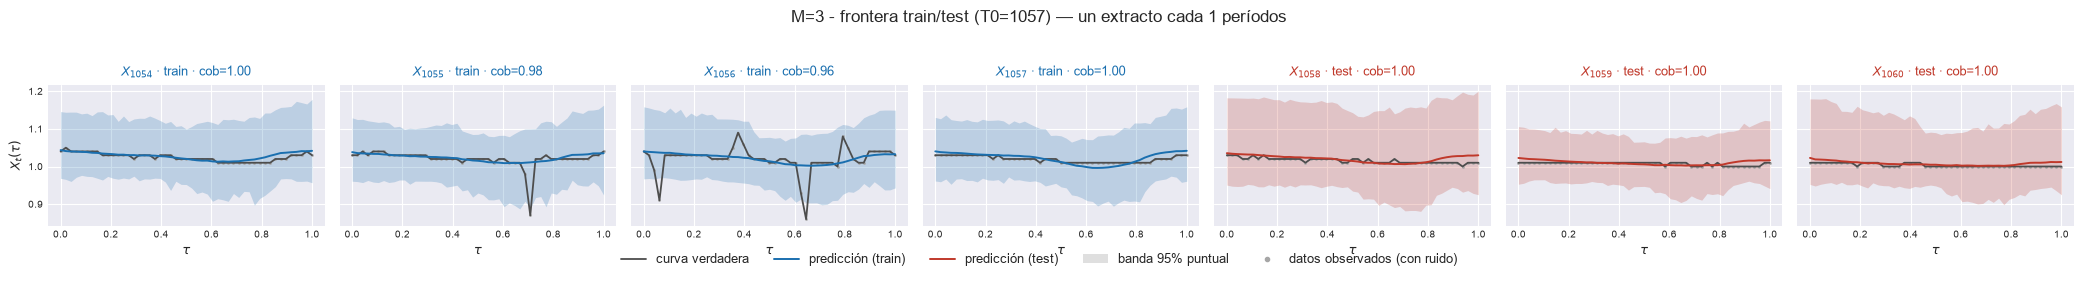

In [17]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
# Es donde se ve, curva a curva, si la banda se ensancha al salir de muestra.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_true_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel],
        grilla, T0, t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL,
        X_obs=X_obs_ev[sel],
        title=f"M={M} - frontera train/test (T0={T0})",
        save_path=str(e["paths"]["out_report"] / "55_extractos_frontera.png"),
        verbose=True)
    plt.show()

[M=1] peores 5 ventanas por rmse_f (w=20, sólo test, sin cruzar T0):
    t=[1136, 1155]  rmse_f=0.053616
    t=[1135, 1154]  rmse_f=0.053584
    t=[1138, 1157]  rmse_f=0.053510
    t=[1137, 1156]  rmse_f=0.053507
    t=[1134, 1153]  rmse_f=0.053429


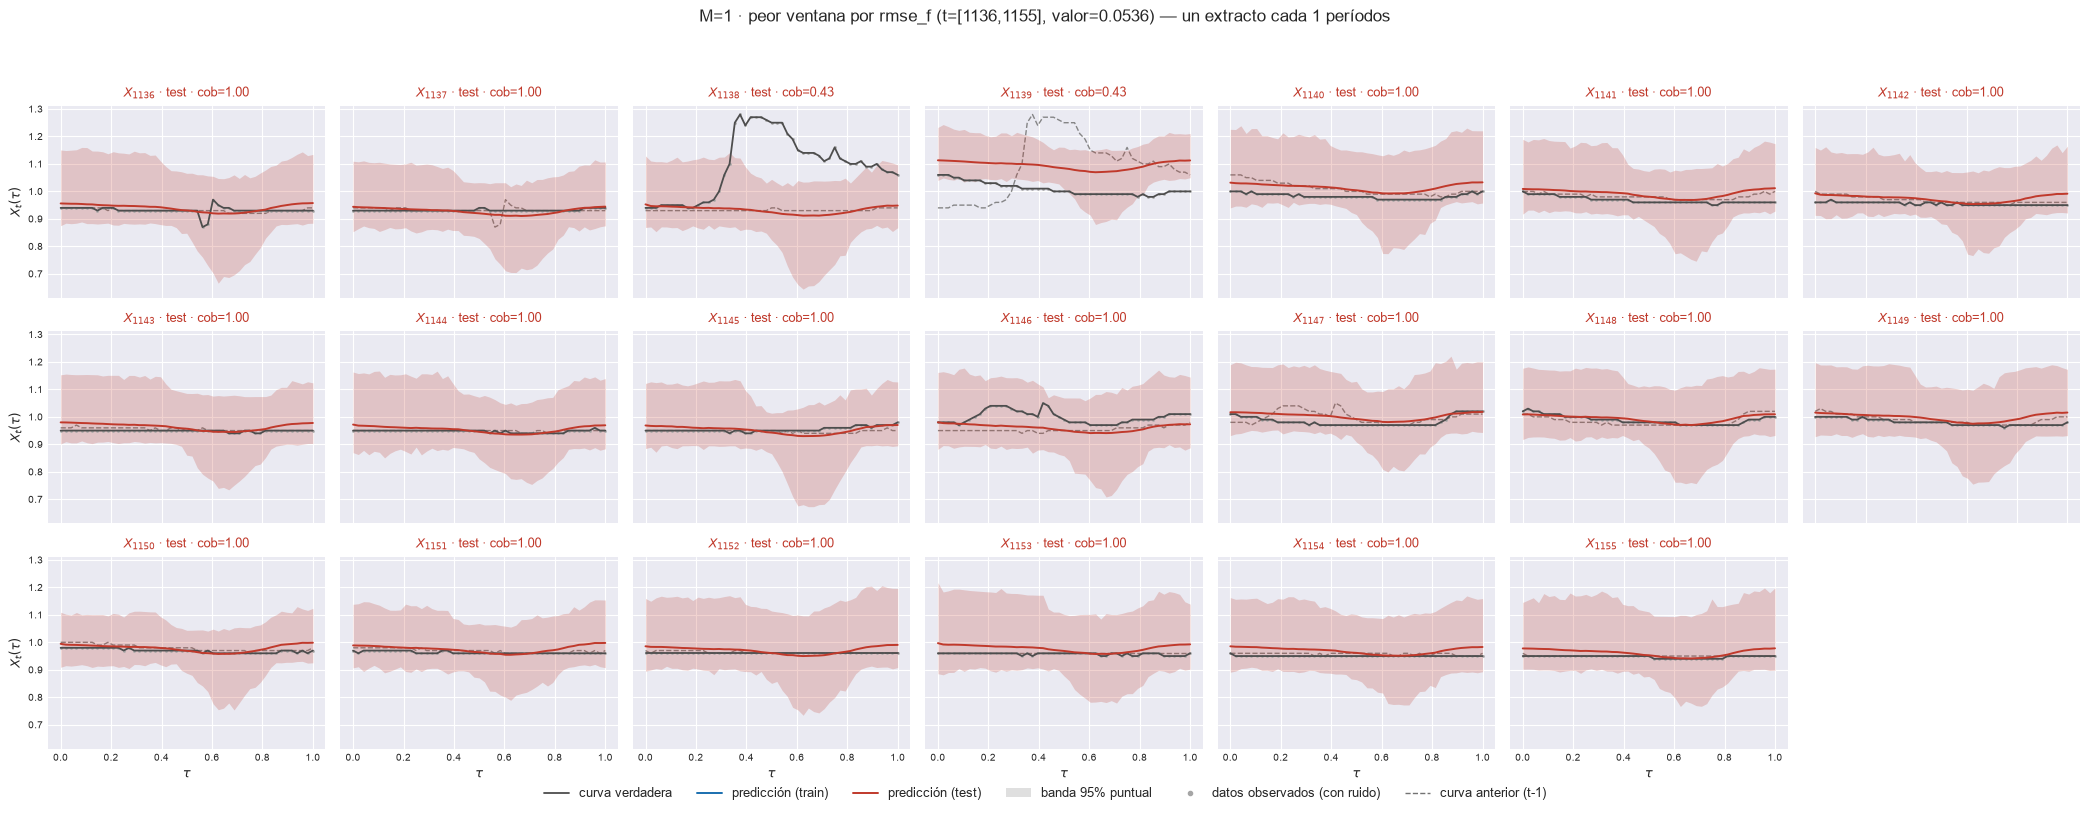

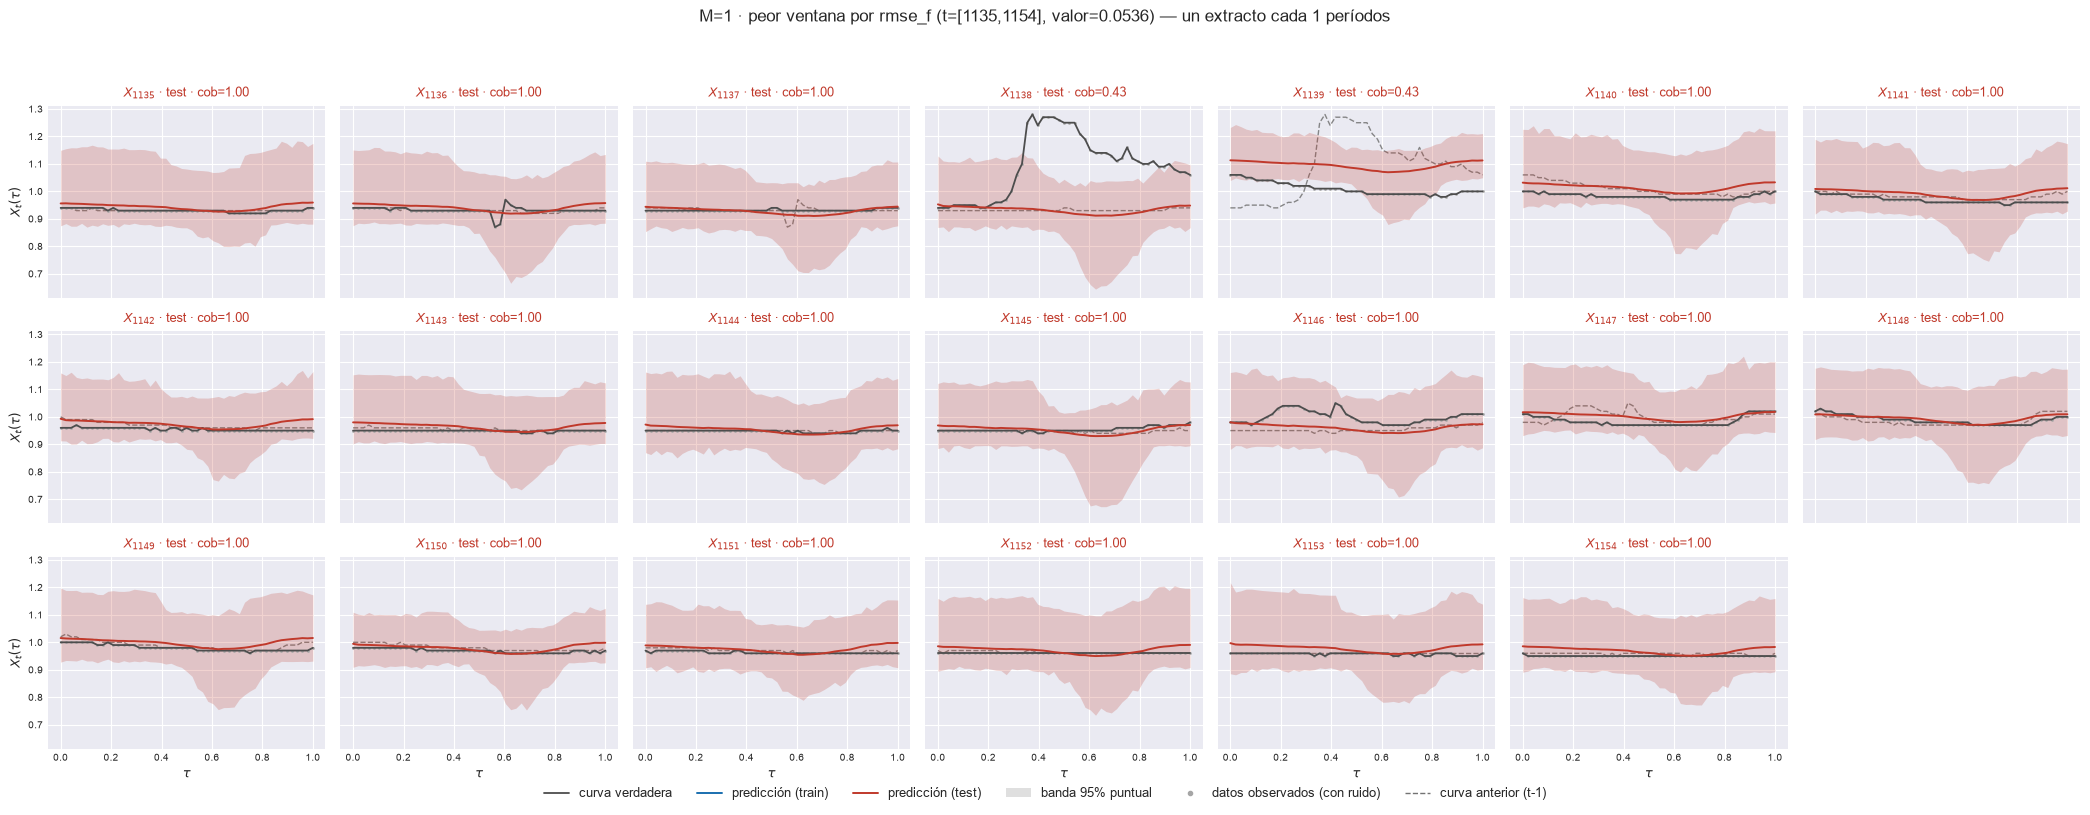

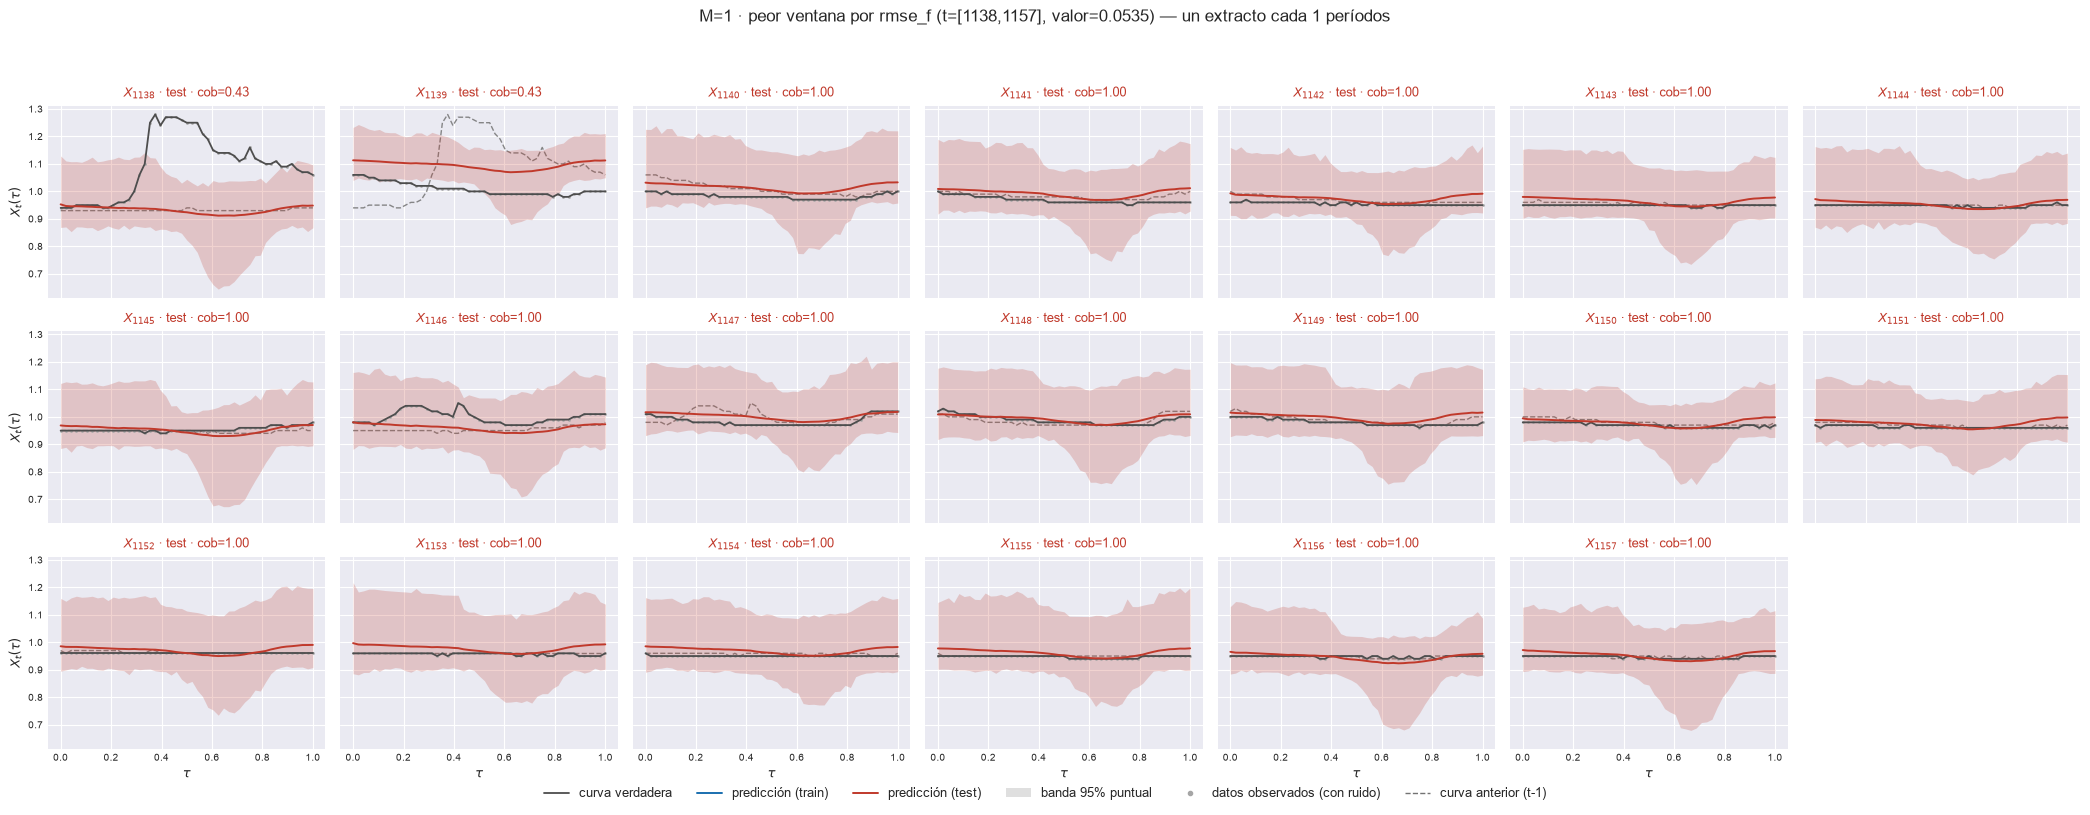

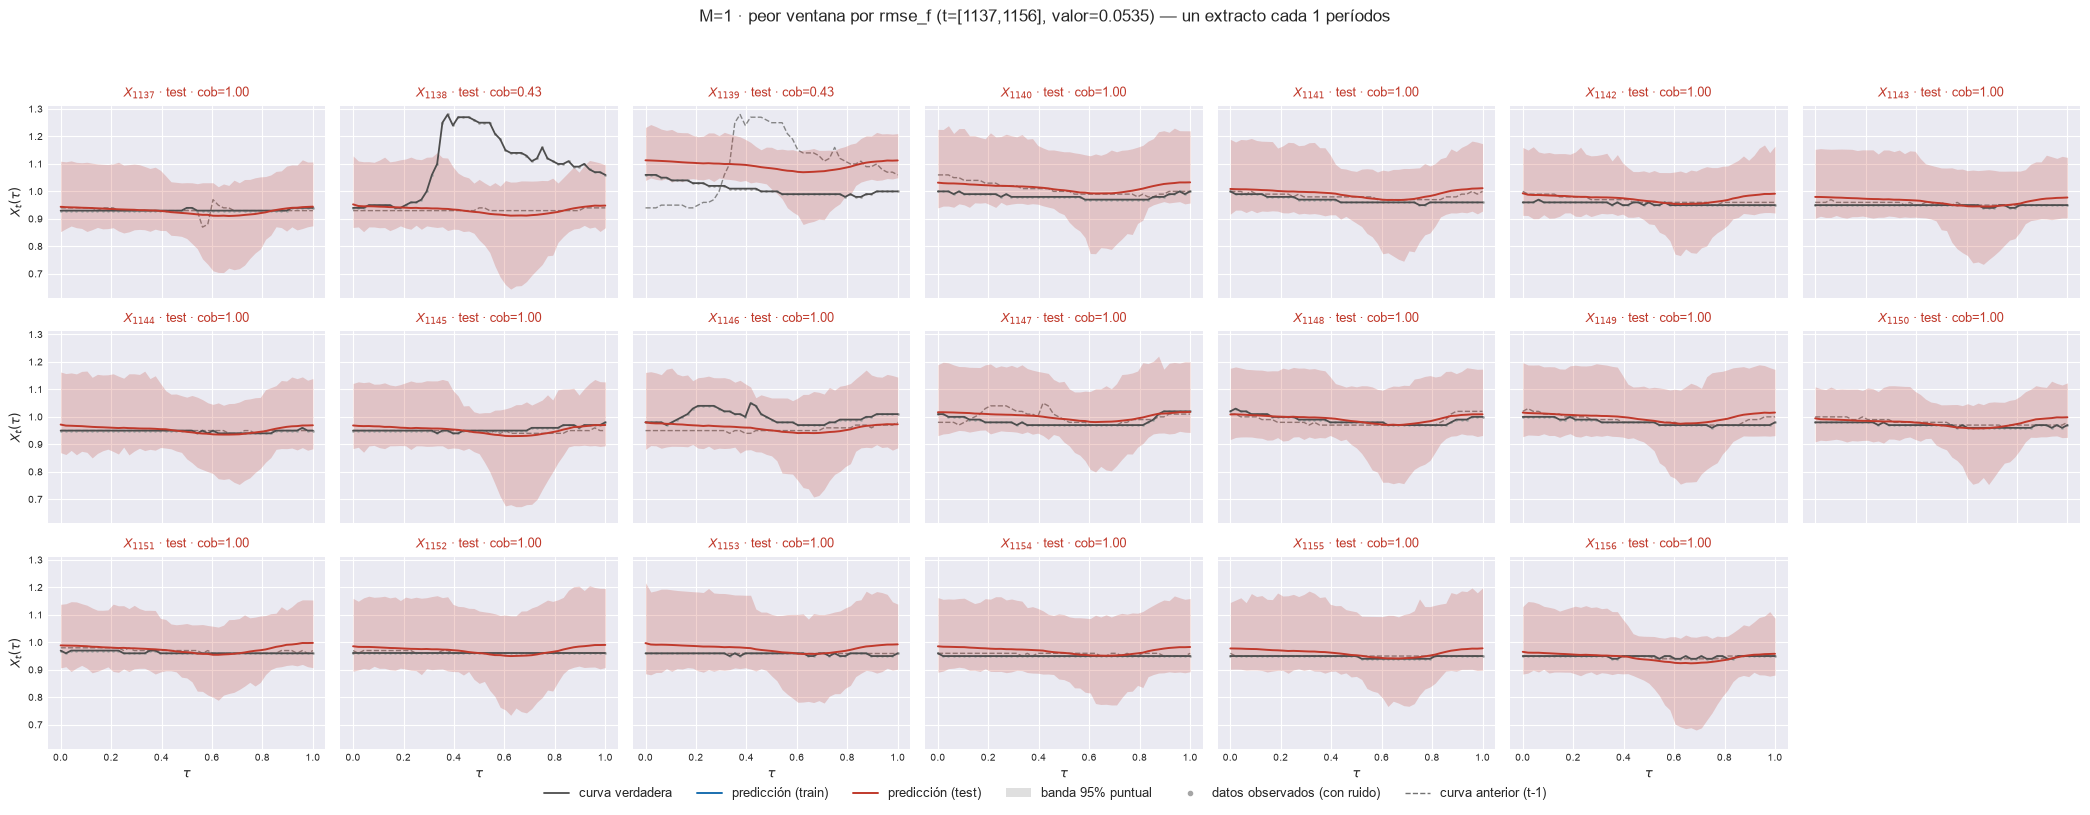

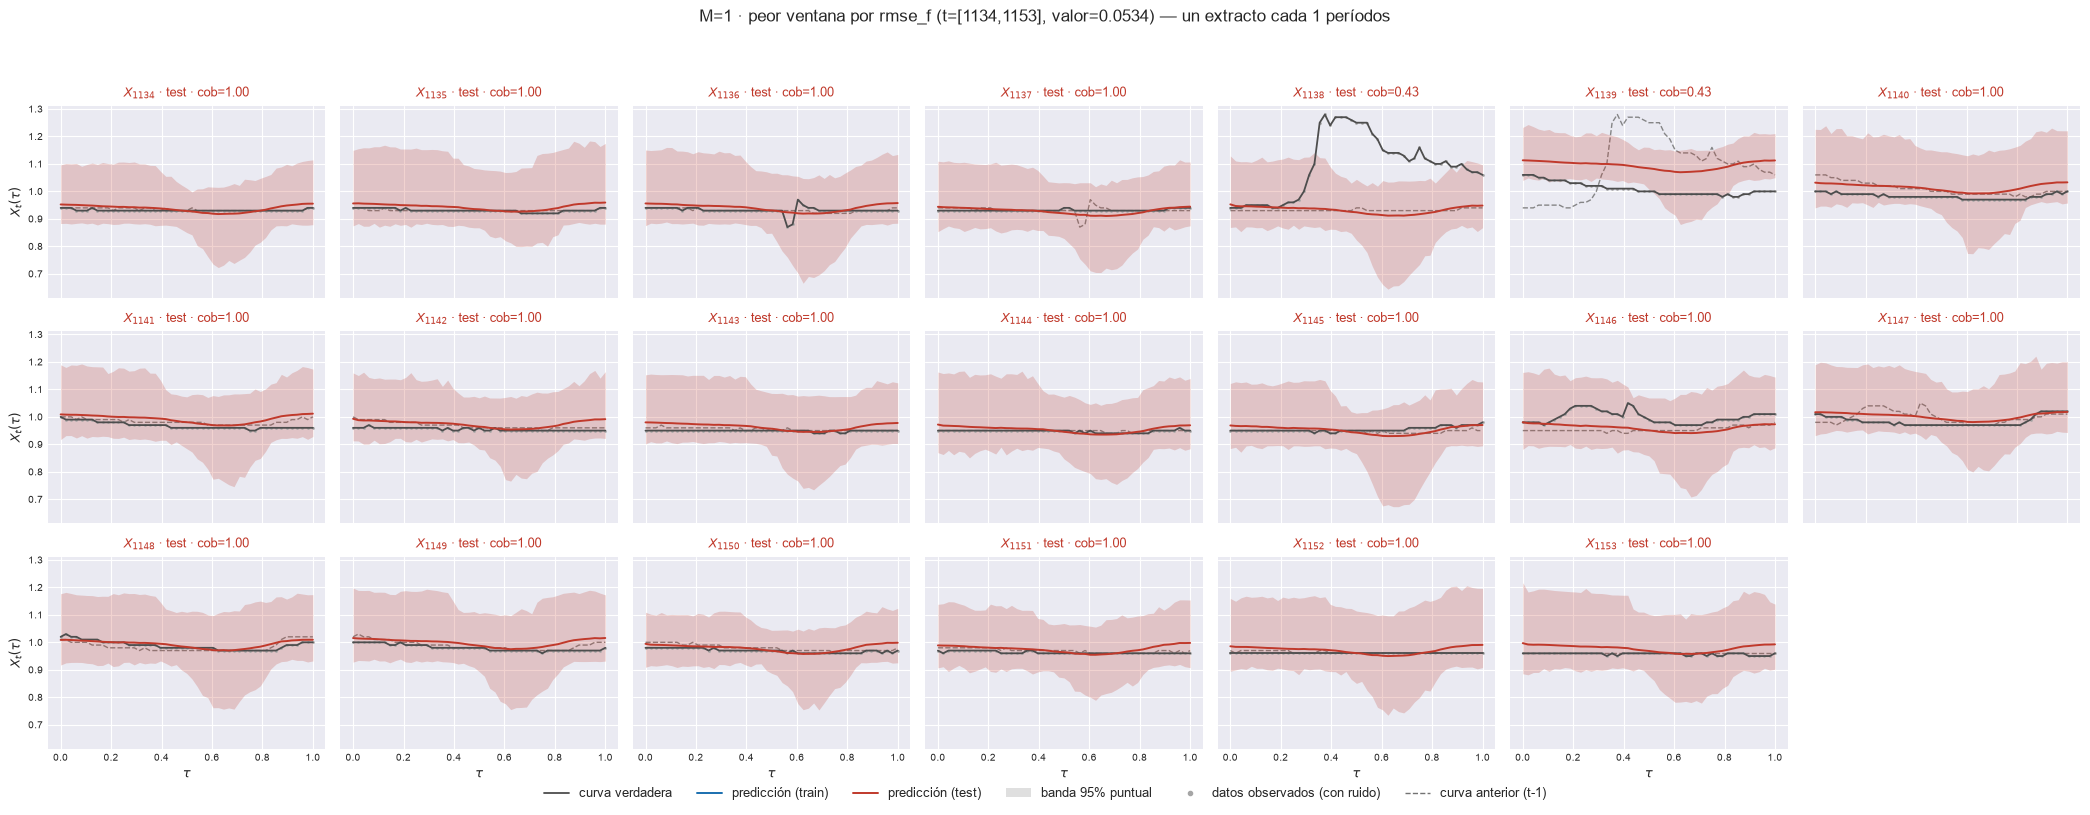

[M=2] peores 5 ventanas por rmse_f (w=20, sólo test, sin cruzar T0):
    t=[1131, 1150]  rmse_f=0.053736
    t=[1132, 1151]  rmse_f=0.053718
    t=[1128, 1147]  rmse_f=0.053715
    t=[1130, 1149]  rmse_f=0.053715
    t=[1127, 1146]  rmse_f=0.053662


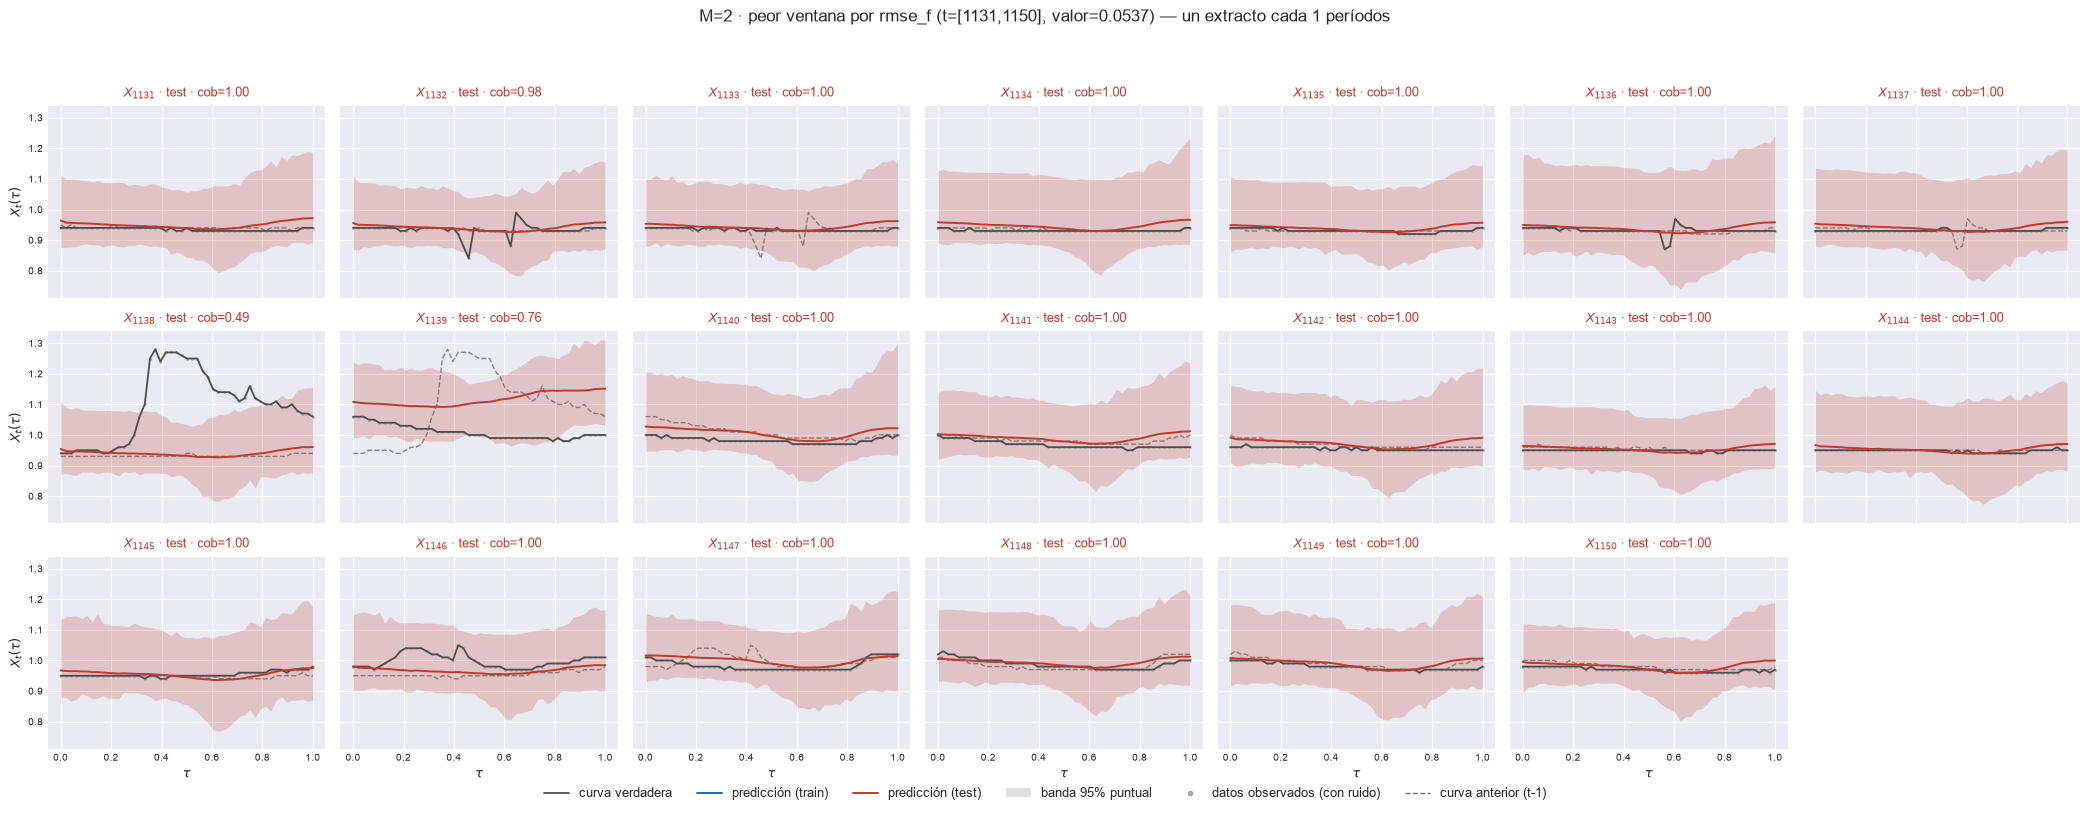

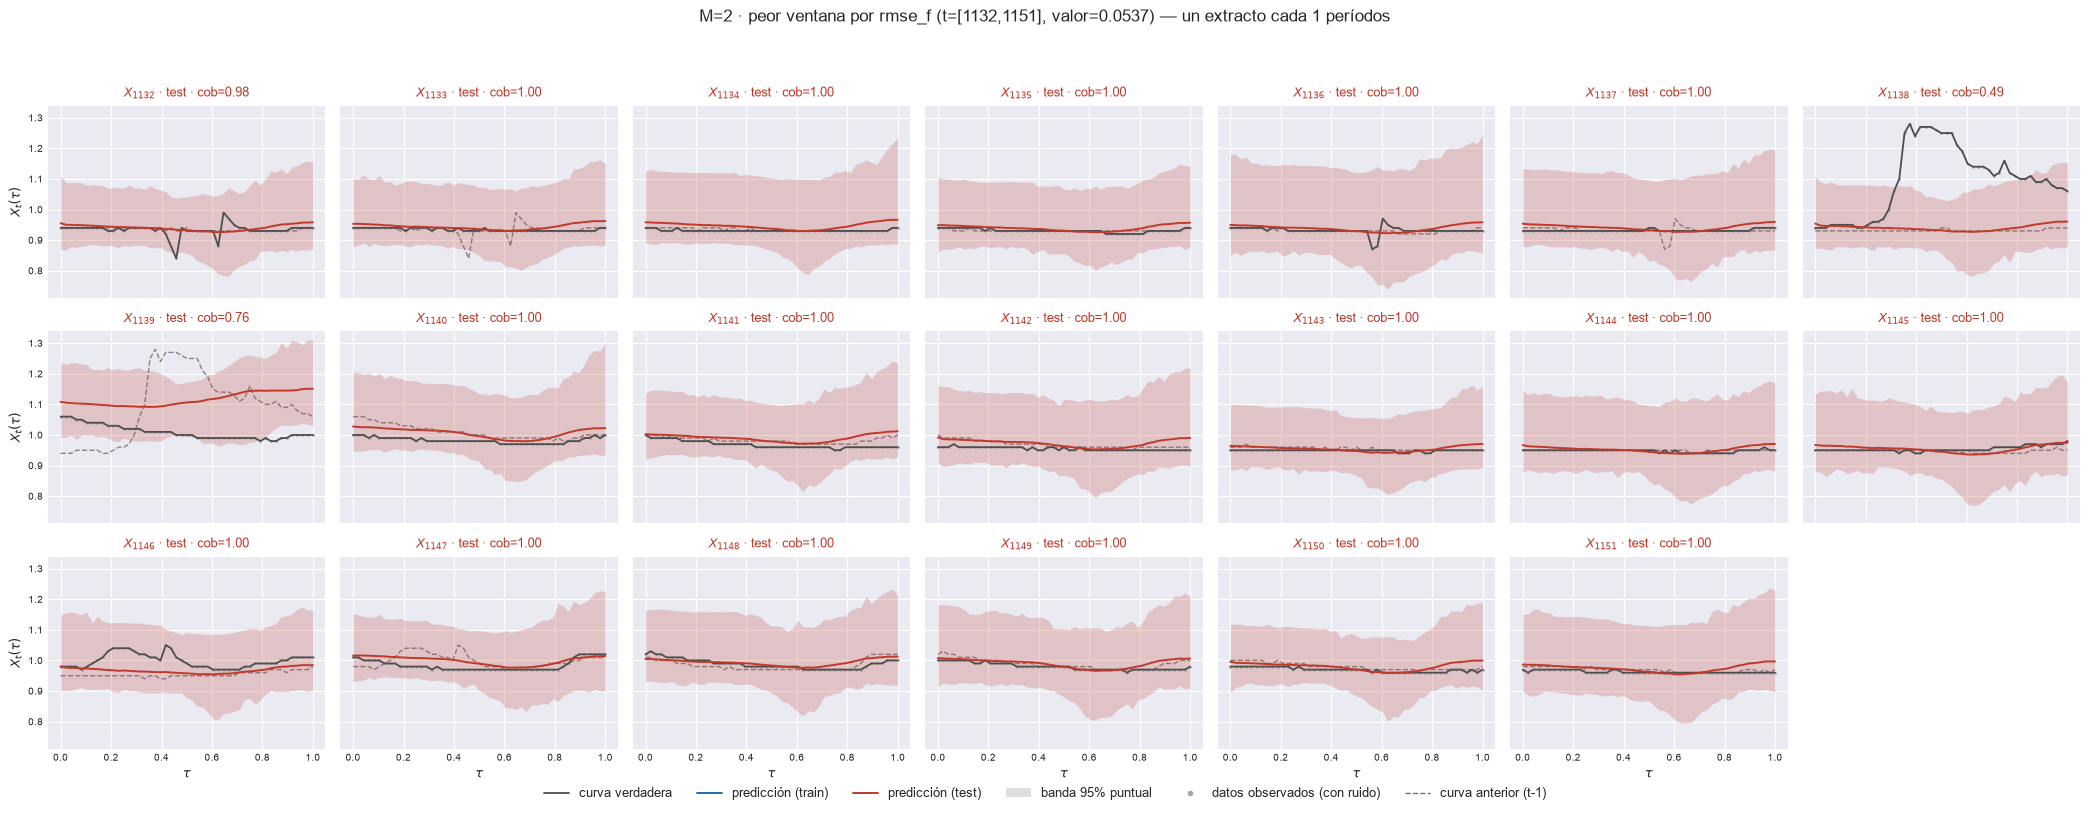

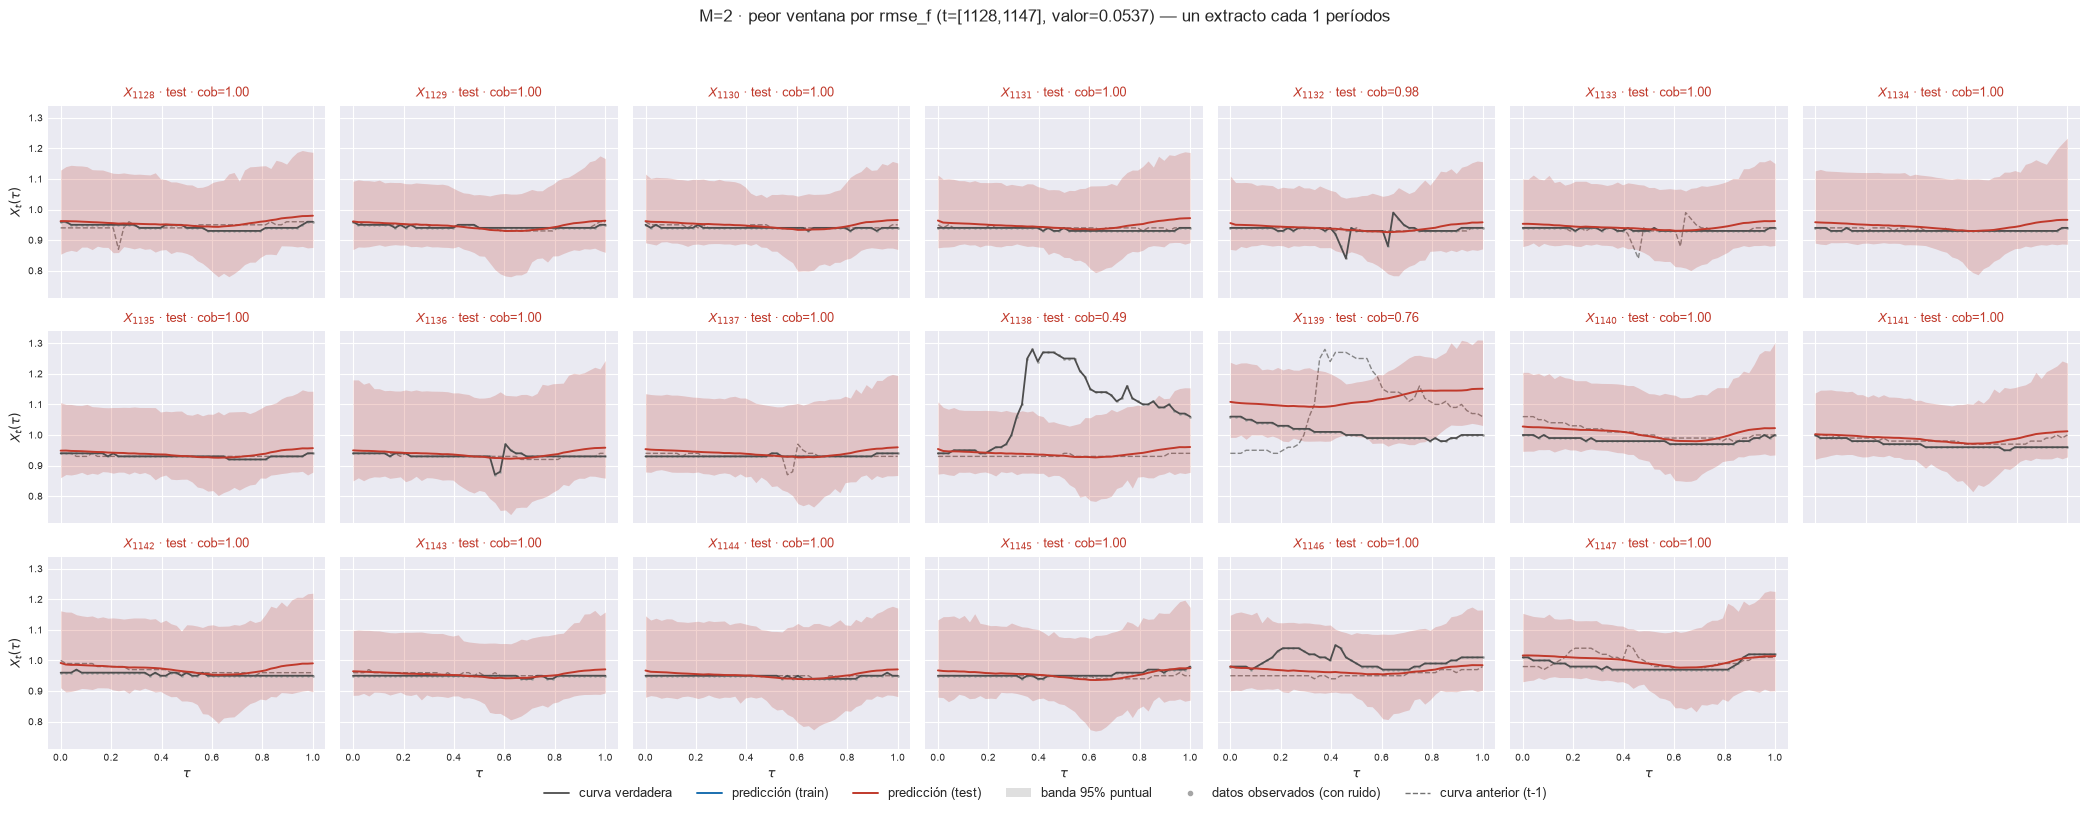

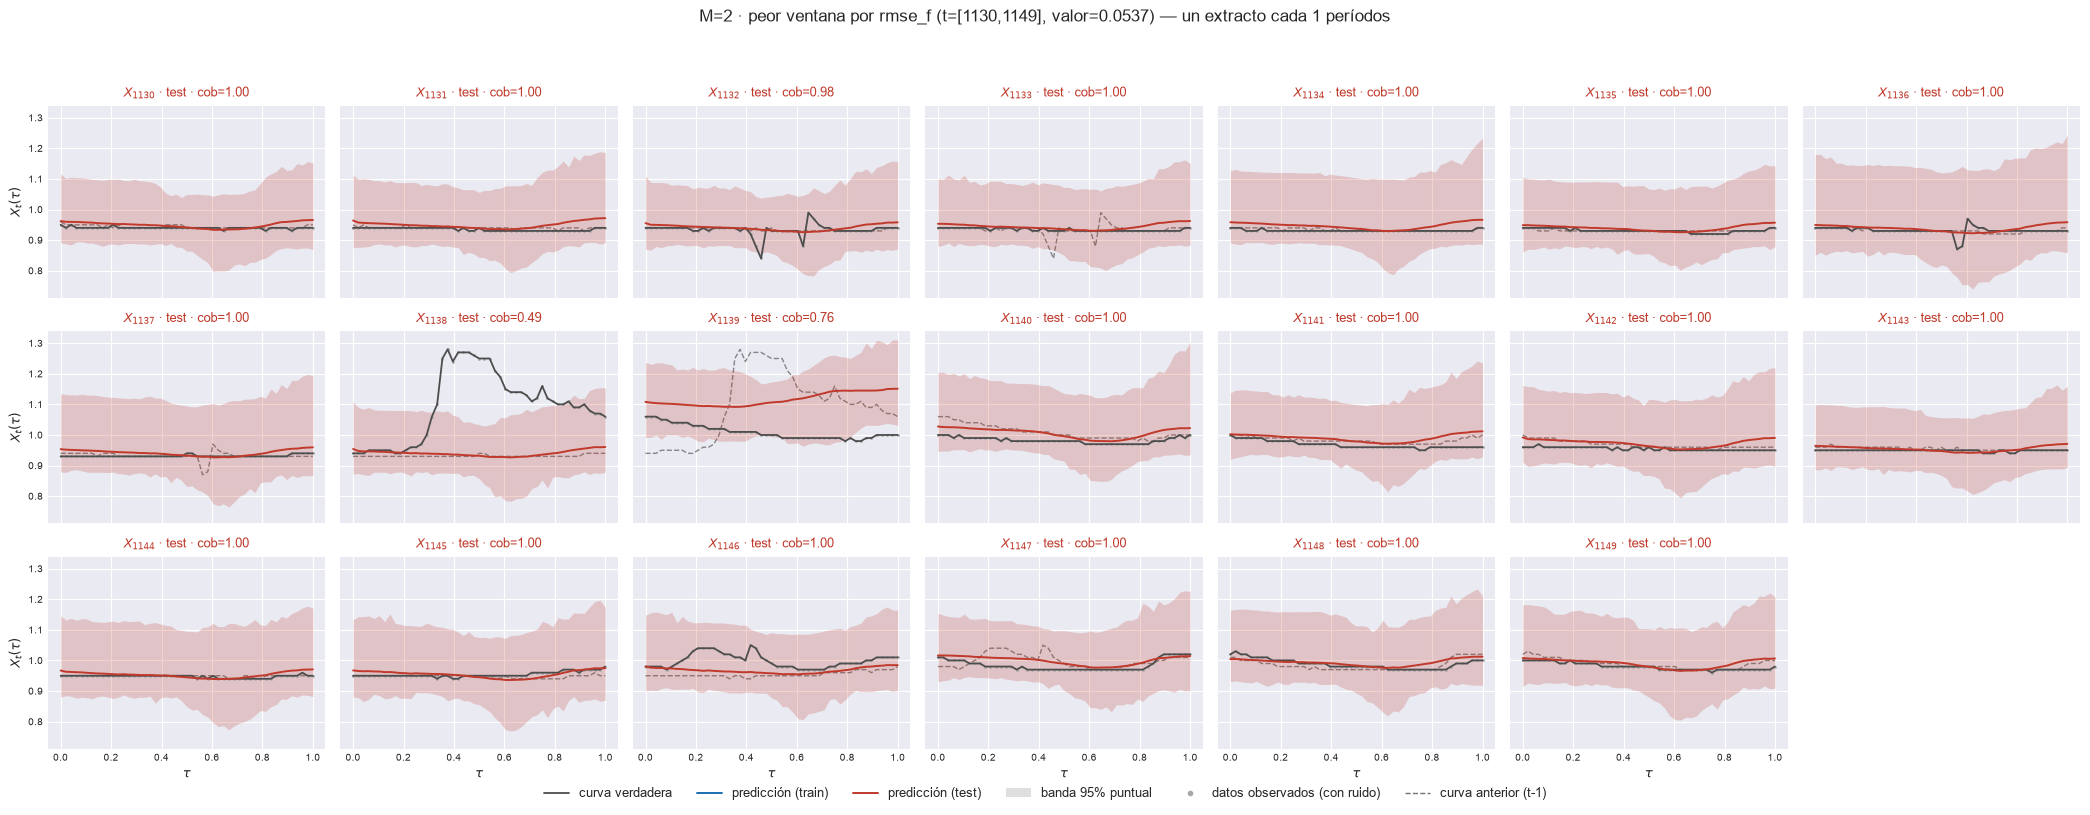

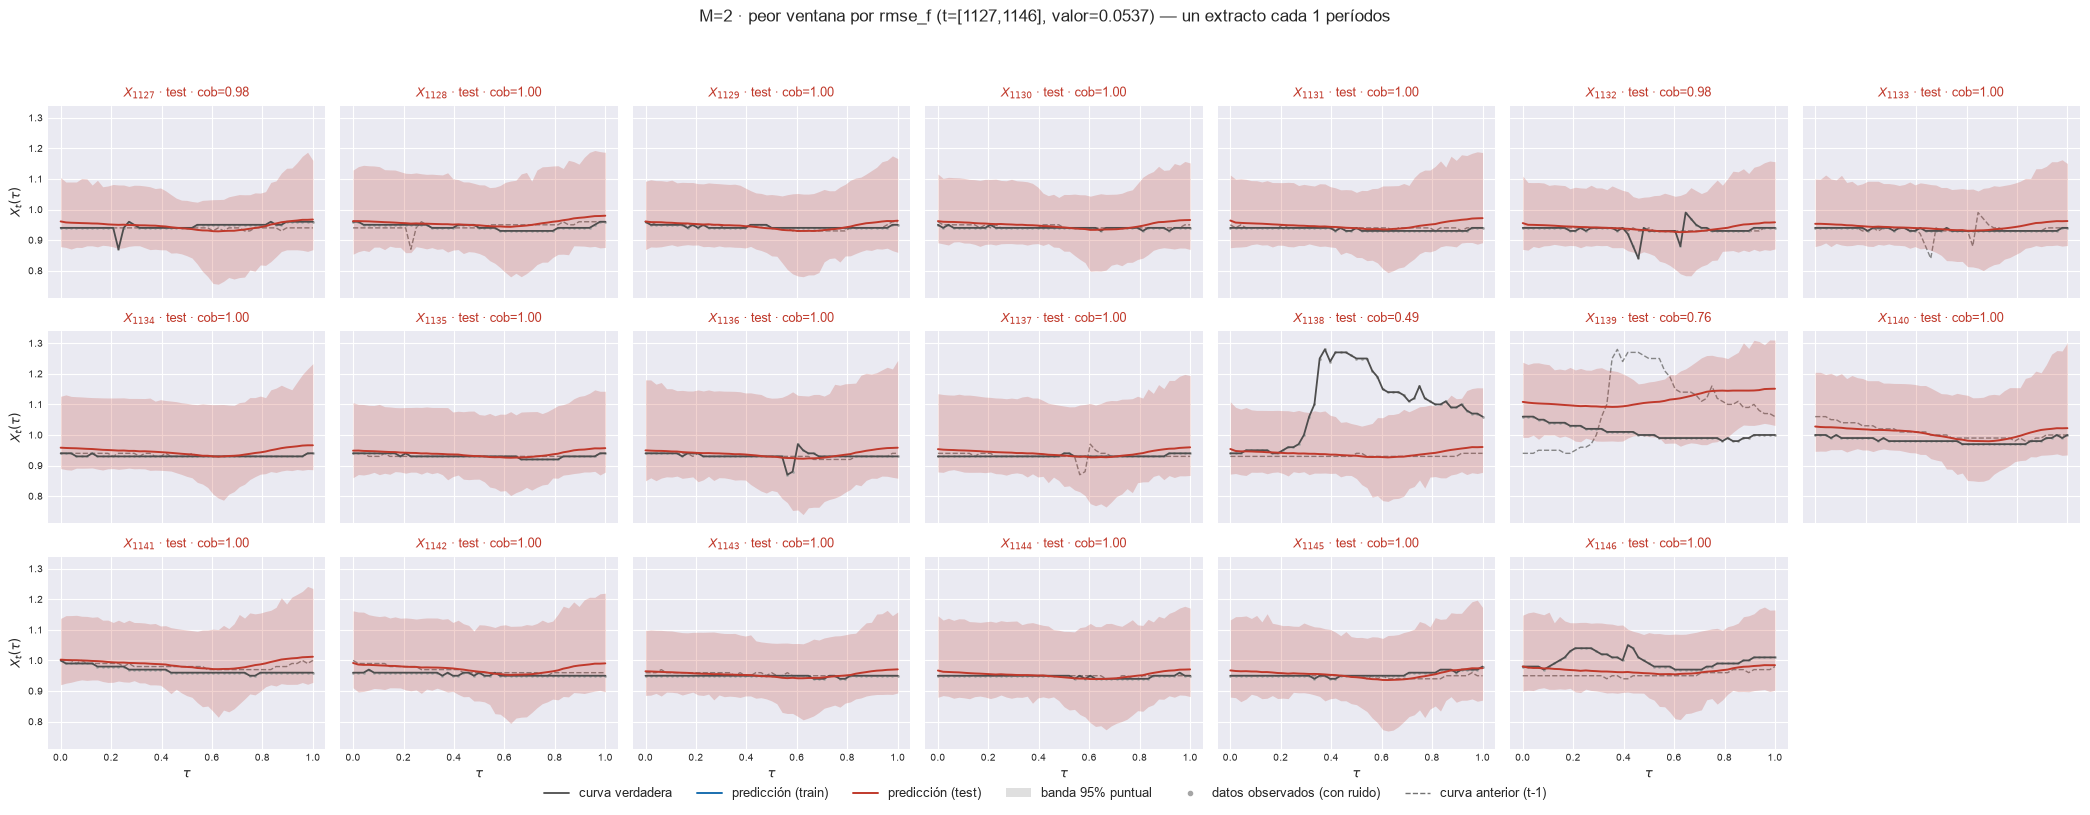

[M=3] peores 5 ventanas por rmse_f (w=20, sólo test, sin cruzar T0):
    t=[1128, 1147]  rmse_f=0.052072
    t=[1132, 1151]  rmse_f=0.052066
    t=[1131, 1150]  rmse_f=0.052061
    t=[1130, 1149]  rmse_f=0.052044
    t=[1127, 1146]  rmse_f=0.052043


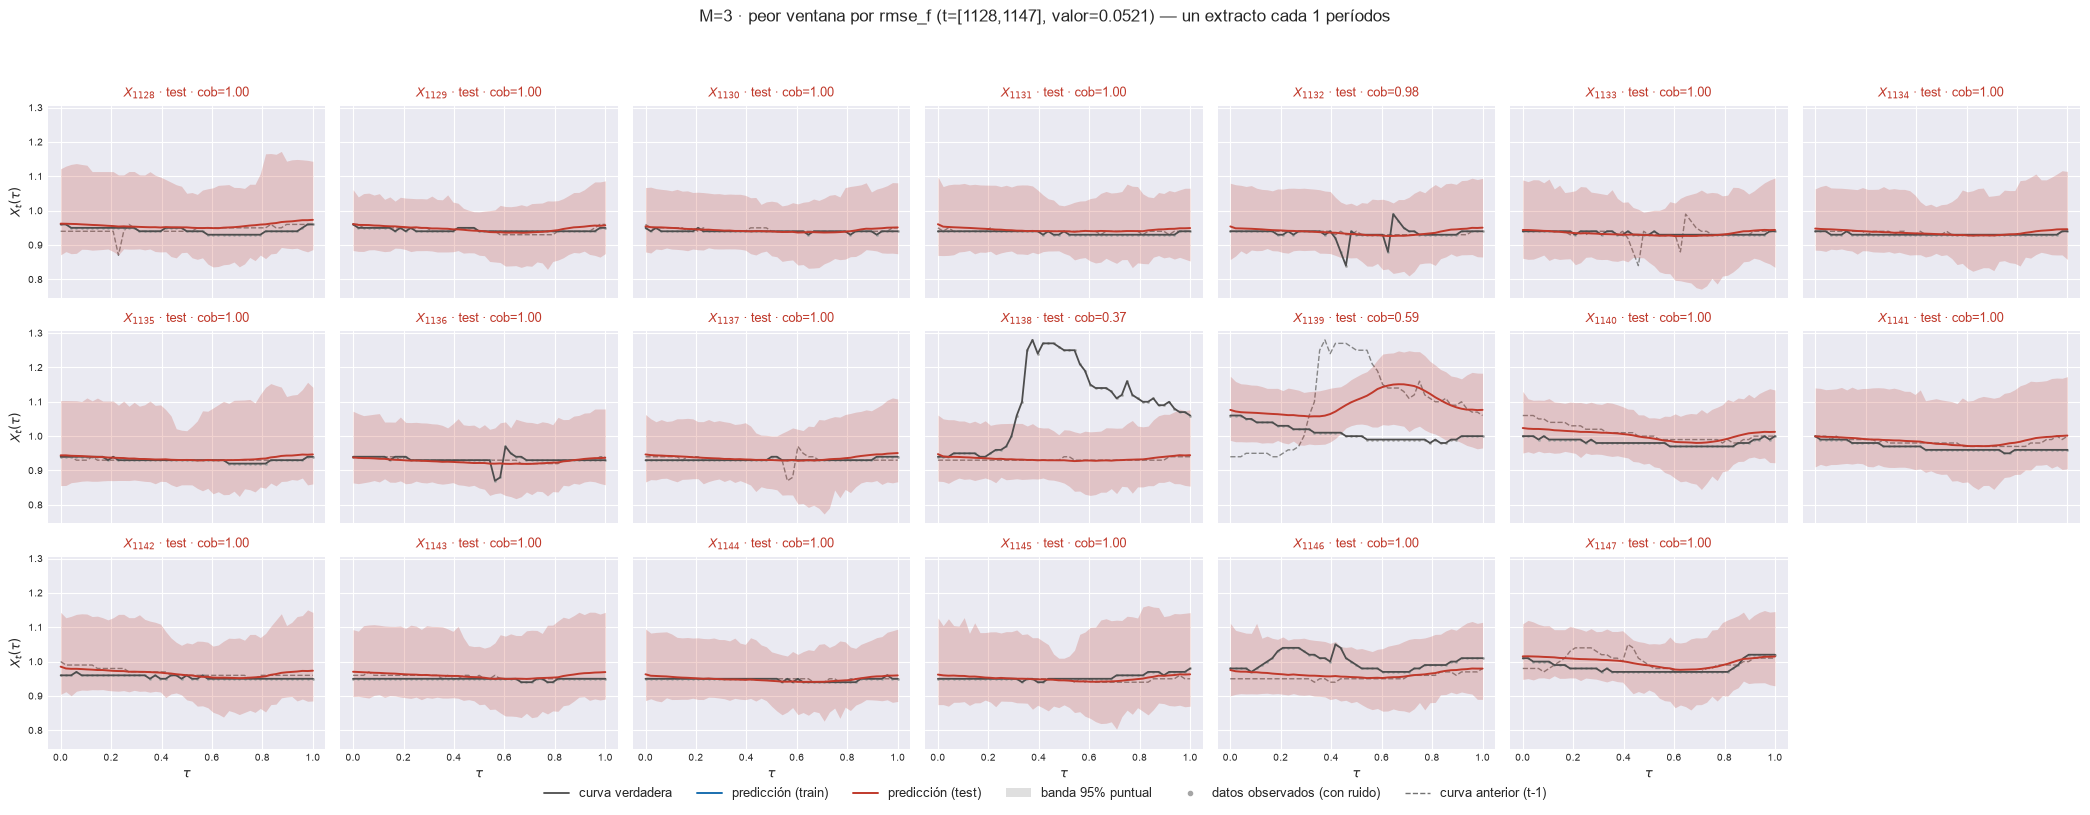

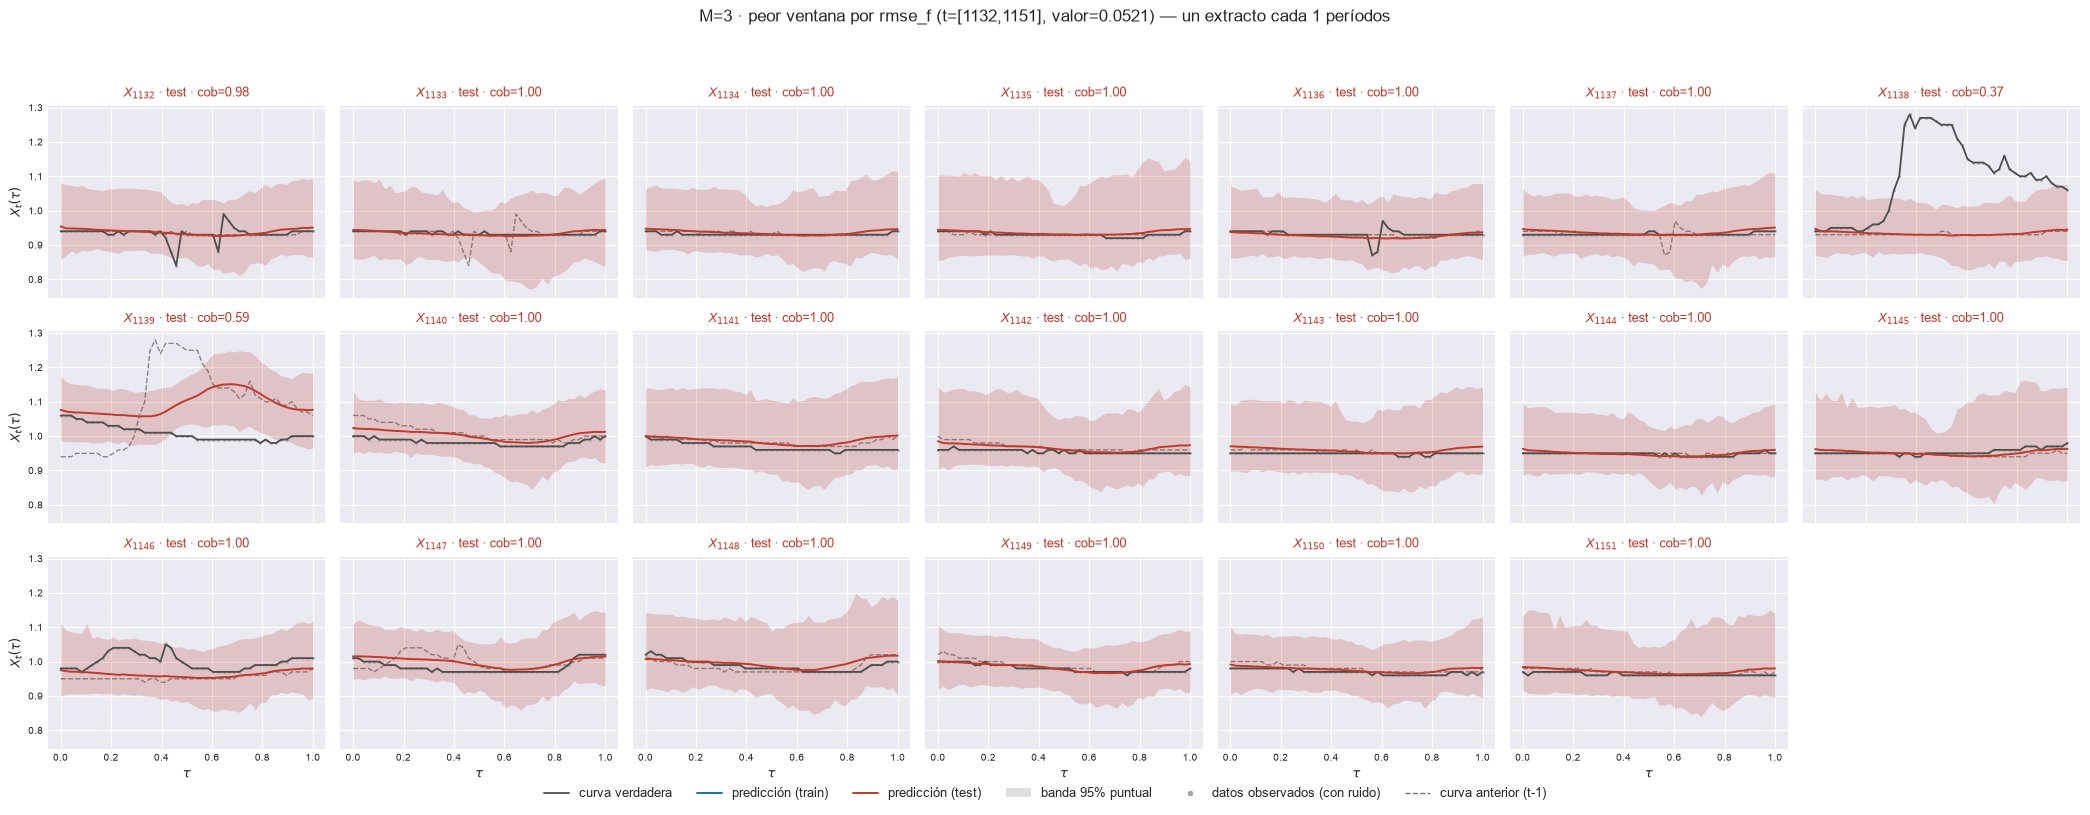

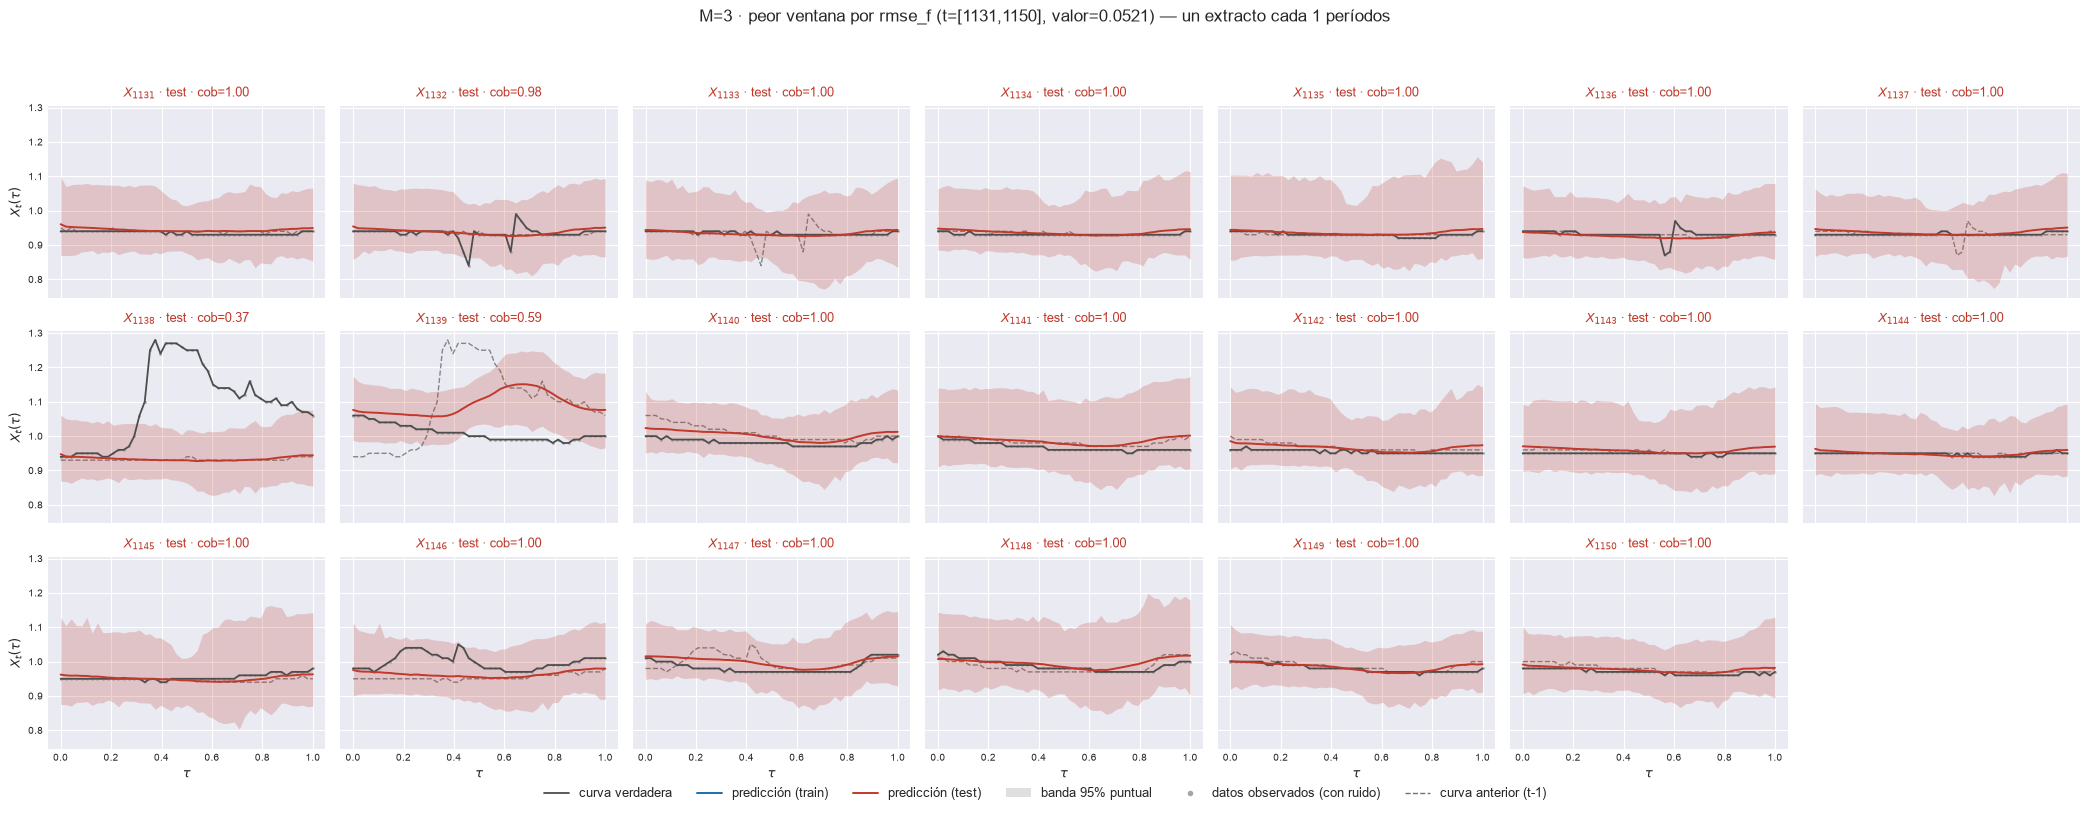

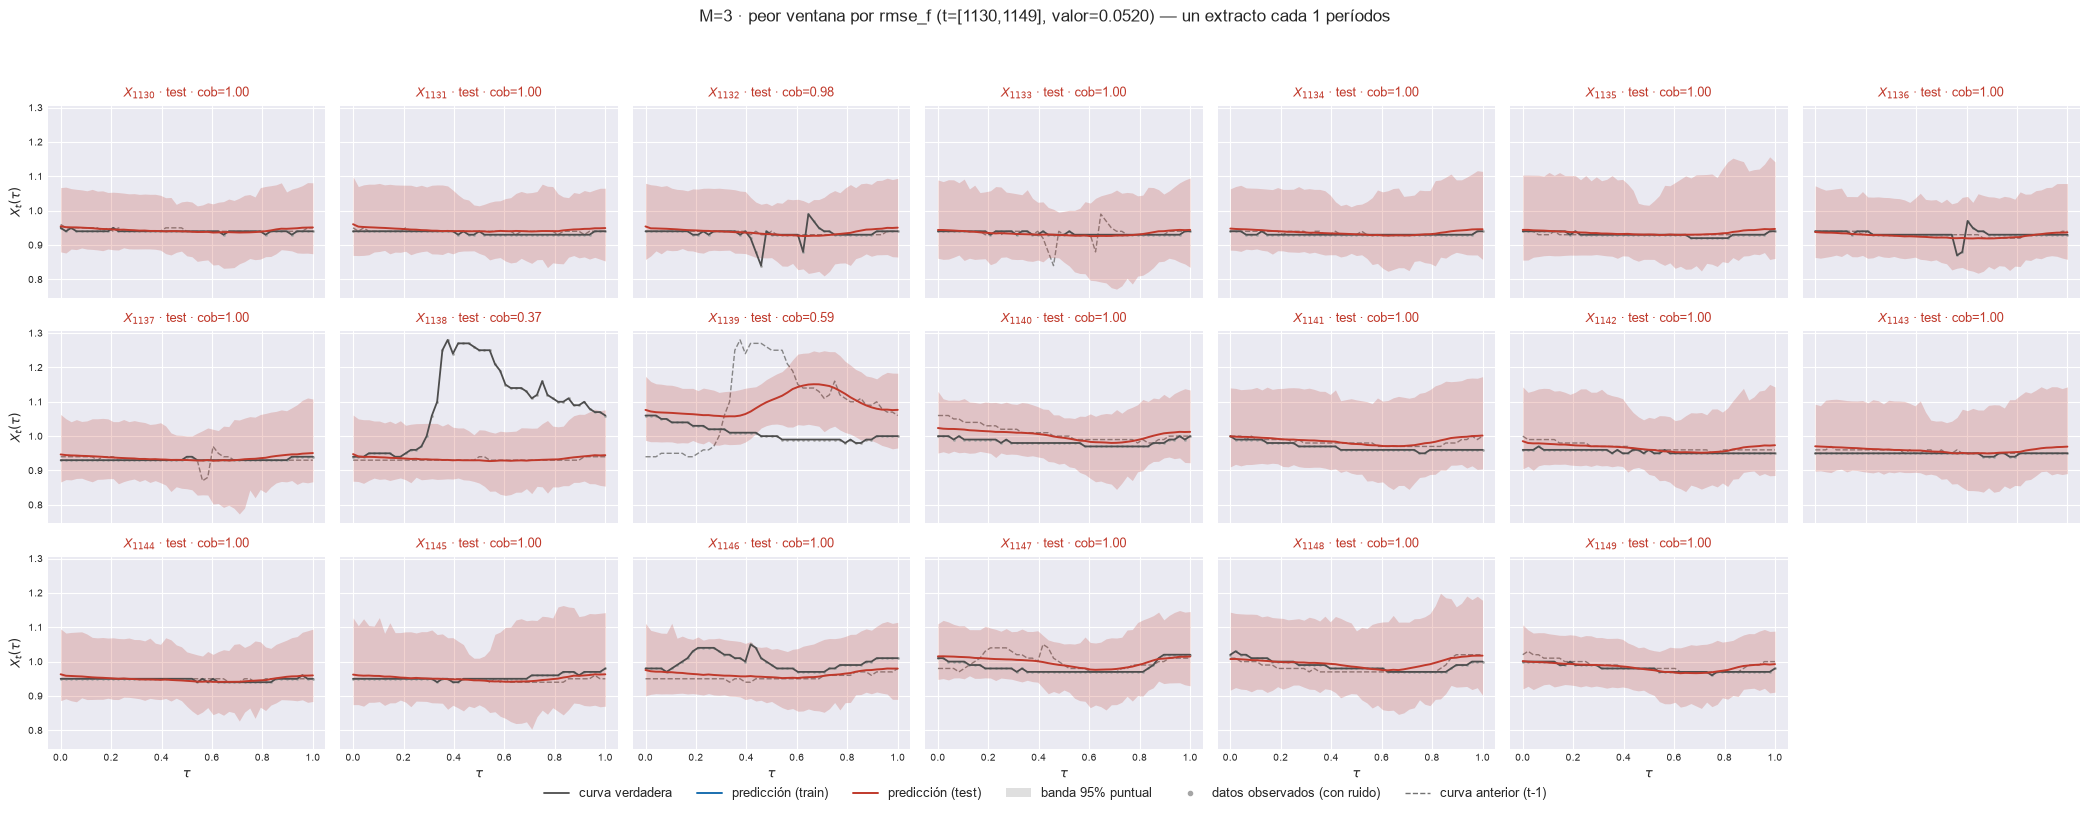

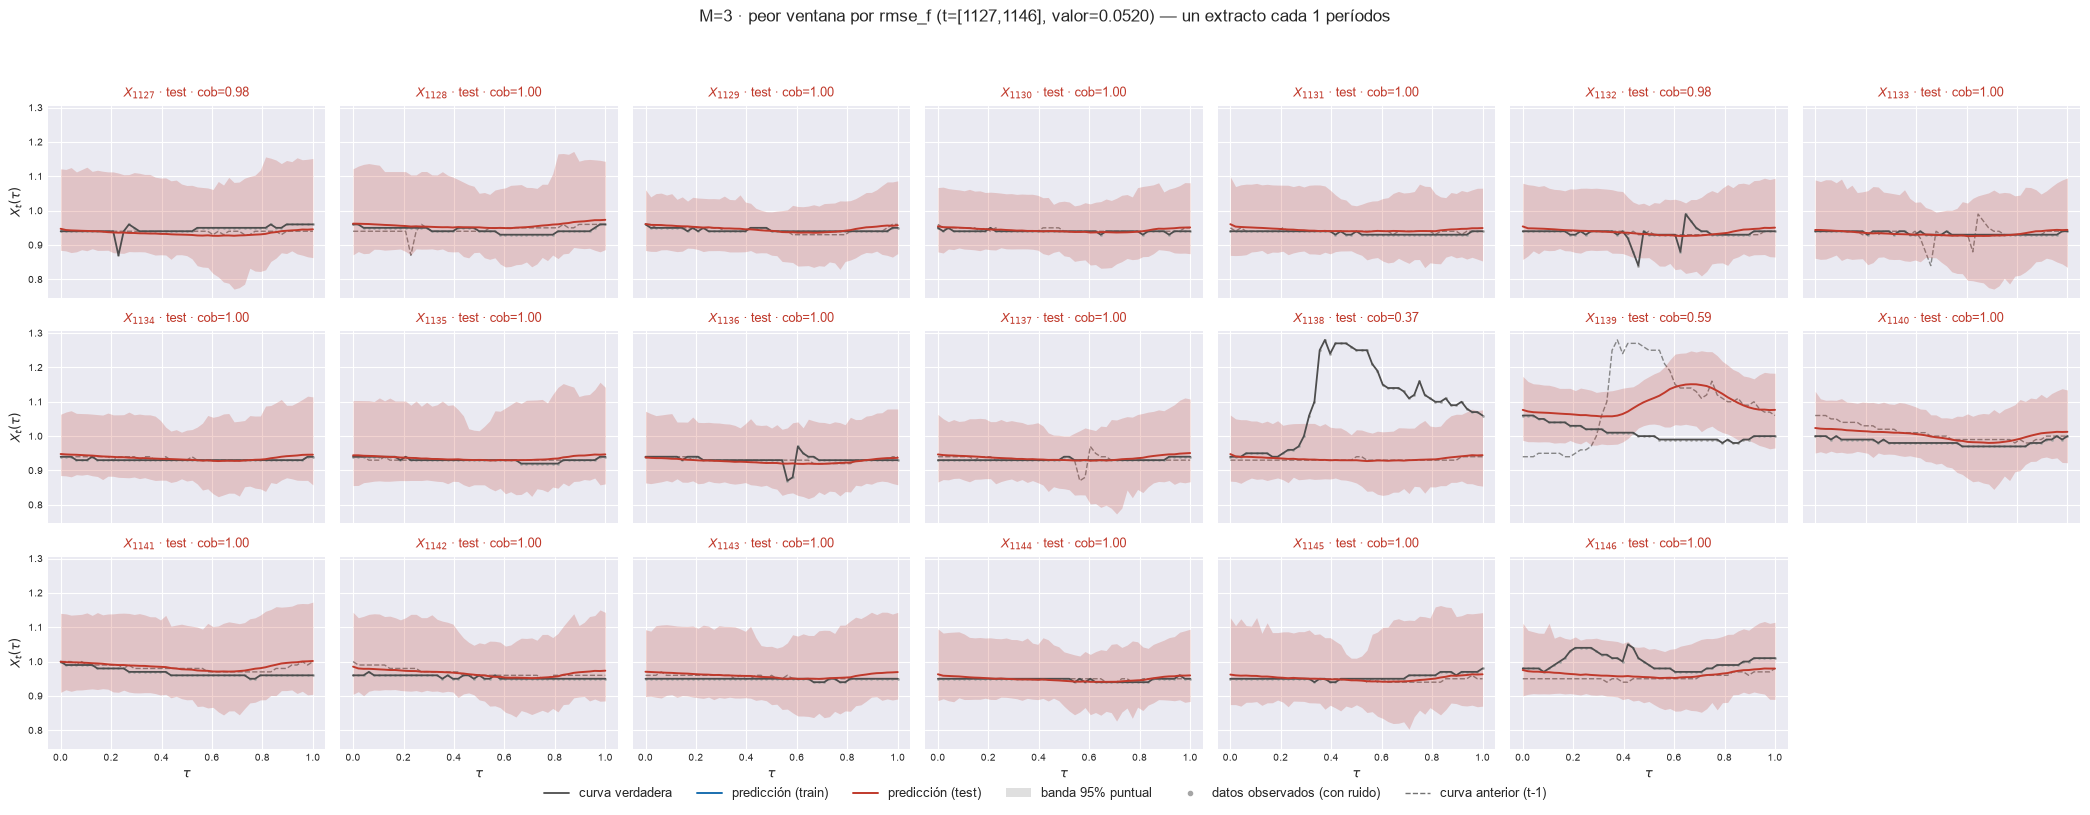

In [18]:
X_prev_full = np.full_like(X_true_ev, np.nan)
X_prev_full[1:] = X_true_ev[:-1]

for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]
    candidatas = tfun[(tfun["bloque"] == "test") & (~tfun["cruza_T0"])]
    if METRICA_PEORES not in candidatas.columns:
        print(f"[M={M}] {METRICA_PEORES!r} no esta en la tabla de ventana; "
              "revisa METRICA_PEORES en [CONFIG].")
        continue
    peores = candidatas.nlargest(N_PEORES, METRICA_PEORES)

    print(f"[M={M}] peores {len(peores)} ventanas por {METRICA_PEORES} "
          f"(w={W_REF}, sólo test, sin cruzar T0):")
    for _, row in peores.iterrows():
        print(f"    t=[{int(row['t_ini'])}, {int(row['t_fin'])}]  "
              f"{METRICA_PEORES}={row[METRICA_PEORES]:.6f}")

    for _, row in peores.iterrows():
        t_ini_exp, t_fin_exp = int(row["t_ini"]), int(row["t_fin"])
        sel = np.where((t_orig >= t_ini_exp) & (t_orig <= t_fin_exp))[0]
        if sel.size == 0:
            continue
        plot_extractos_curvas(
            X_true_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel],
            grilla, T0, t=t_orig[sel], cada=1, n_col=min(len(sel), 7),
            nivel=NIVEL, X_obs=X_obs_ev[sel], X_prev=X_prev_full[sel],
            title=f"M={M} · peor ventana por {METRICA_PEORES} "
                  f"(t=[{t_ini_exp},{t_fin_exp}], valor={row[METRICA_PEORES]:.4f})",
            save_path=str(e["paths"]["out_report"]
                          / f"56b_peor_ventana_{METRICA_PEORES}_t{t_ini_exp}.png"),
            verbose=False)
        plt.show()


## 7. Probabilidades posteriores de inclusión (PIP)

Datos reales: no hay estructura verdadera que contrastar, así que todas las
covariables son candidatas y la cifra útil es `pip_media_activas`.


In [19]:
for M in M_OK:
    e = EST[M]
    pip_df = matriz_pip(e["models_chains"], e["burn"],
                        component_idx=e["component_idx"], verbose=True)
    pip_df.to_csv(e["paths"]["out_report"] / "46_pip.csv")
    e["pip_df"] = pip_df

    cols_pip = [c for c in pip_df.columns if not c.endswith("_sd")]
    display(pip_df.style
        .background_gradient(subset=cols_pip, cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.3f}")
        .set_caption(f"M={M} · P(gamma_j = 1 | datos), inclusión global, "
                     "media entre cadenas ± sd"))

    sd_cols = [c for c in pip_df.columns if c.endswith("_sd")]
    sd_max = float(pip_df[sd_cols].to_numpy().max()) if sd_cols else float("nan")
    e["pip_sd_max"] = sd_max
    print(f"[M={M}] dispersión máxima entre cadenas: {sd_max:.3f}"
          + ("   ! las cadenas discrepan sobre la selección" if sd_max > 0.15
             else "   OK las cadenas coinciden"))


[matriz_pip] inicio (1 pasos)
  1/1 (100.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 1 variables, PIP en [1.000, 1.000]
[matriz_pip] listo: 1 pasos en 0.0s  tabla 1x2


,FPC 1,FPC 1_sd
variable,,
fpc_1_lag1,1.000,0.000


[M=1] dispersión máxima entre cadenas: 0.000   OK las cadenas coinciden
[matriz_pip] inicio (2 pasos)
  1/2 (50.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 2 variables, PIP en [1.000, 1.000]
  2/2 (100.0%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 2 variables, PIP en [1.000, 1.000]
[matriz_pip] listo: 2 pasos en 0.0s  tabla 2x4


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd
variable,,,,
fpc_1_lag1,1.000,0.000,1.000,0.000
fpc_2_lag1,1.000,0.000,1.000,0.000


[M=2] dispersión máxima entre cadenas: 0.000   OK las cadenas coinciden
[matriz_pip] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 3 variables, PIP en [1.000, 1.000]
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 3 variables, PIP en [0.500, 1.000]
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3: 2 cadenas, 3 variables, PIP en [1.000, 1.000]
[matriz_pip] listo: 3 pasos en 0.0s  tabla 3x6


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd,FPC 3,FPC 3_sd
variable,,,,,,
fpc_1_lag1,1.000,0.000,0.500,0.304,1.000,0.000
fpc_2_lag1,1.000,0.000,1.000,0.000,1.000,0.000
fpc_3_lag1,1.000,0.000,1.000,0.000,1.000,0.000


[M=3] dispersión máxima entre cadenas: 0.304   ! las cadenas discrepan sobre la selección


In [20]:
for M in M_OK:
    e = EST[M]
    # Datos reales: sin estructura verdadera. Todas las covariables son candidatas.
    VERDAD = {f"FPC {e['component_idx'][k] + 1}": list(e["cov_names"])
              for k in range(e["n_components"])}

    contraste = contraste_con_verdad(e["pip_df"], VERDAD, umbral=0.5)
    e["contraste"] = contraste
    if not contraste.empty:
        contraste.to_csv(e["paths"]["out_report"] / "47_contraste_pip.csv")
        display(contraste.style.format("{:.3f}", subset=[
            c for c in contraste.columns if contraste[c].dtype.kind == "f"])
            .set_caption(f"M={M} · selección de variables, todas candidatas "
                         "inclusión (umbral 0.5)"))

print("Con todas las covariables activas, especificidad y AUC no están "
      "definidas de forma informativa: la cifra útil es `pip_media_activas`.")


,n_activas,VP,FP,FN,VN,sensibilidad,especificidad,exactitud,auc,pip_media_activas,pip_media_inactivas
componente,,,,,,,,,,,
FPC 1,1,1,0,0,0,1.000,0.000,1.000,nan,1.000,nan


,n_activas,VP,FP,FN,VN,sensibilidad,especificidad,exactitud,auc,pip_media_activas,pip_media_inactivas
componente,,,,,,,,,,,
FPC 1,2,2,0,0,0,1.000,0.000,1.000,nan,1.000,nan
FPC 2,2,2,0,0,0,1.000,0.000,1.000,nan,1.000,nan


,n_activas,VP,FP,FN,VN,sensibilidad,especificidad,exactitud,auc,pip_media_activas,pip_media_inactivas
componente,,,,,,,,,,,
FPC 1,3,3,0,0,0,1.000,0.000,1.000,nan,1.000,nan
FPC 2,3,3,0,0,0,1.000,0.000,1.000,nan,0.833,nan
FPC 3,3,3,0,0,0,1.000,0.000,1.000,nan,1.000,nan


Con todas las covariables activas, especificidad y AUC no están definidas de forma informativa: la cifra útil es `pip_media_activas`.


## 8. Cuadro resumen: mínimo, máximo y promedio

La ventana móvil genera una SERIE por métrica, no una cifra. Esta tabla es la
lectura resumida de esa serie: mínimo, máximo y promedio, por bloque
train/test, excluyendo las ventanas que cruzan $T_0$ -su cifra mezcla dentro y
fuera de muestra-. Cubre las 7 métricas de los Bloques A y B; ninguna se
destaca sobre las demás.

In [21]:
METRICAS_RESUMEN = METRICAS_A + METRICAS_B   # las 6 con lectura por ventana

resumen_M = []
for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]
    limpio = tfun[~tfun["cruza_T0"]]

    filas = []
    for etiqueta, col in METRICAS_RESUMEN:
        for bloque in ("train", "test"):
            v = limpio.loc[limpio.bloque == bloque, col]
            filas.append({"metrica": etiqueta, "columna": col, "bloque": bloque,
                          "minimo": float(v.min()), "maximo": float(v.max()),
                          "promedio": float(v.mean())})
    resumen = pd.DataFrame(filas).set_index(["metrica", "bloque"])
    resumen.to_csv(e["paths"]["out_report"] / "66_metricas_resumen.csv")
    e["resumen_df"] = resumen

    display(resumen.style
            .format({"minimo": "{:.6f}", "maximo": "{:.6f}", "promedio": "{:.6f}"})
            .set_caption(f"M={M} · mínimo / máximo / promedio por ventana "
                         f"(w={W_REF}, sin cruzar T0) · nivel funcional"))

    picp_pt = float(limpio.loc[limpio.bloque == "test", "picp"].mean())
    picp_si = float(limpio.loc[limpio.bloque == "test", "picp_simultaneo"].mean())
    print(f"[M={M}] PICP puntual test = {picp_pt:.4f} (nominal {NIVEL:.2f})  ·  "
          f"PICP simultáneo test = {picp_si:.4f}")

    # El indicador I_t por origen, en sus dos versiones -de las que (picp) y
    # (picp_simultaneo) son el promedio-. Se persiste porque el promedio
    # esconde DONDE falla la banda.
    I_t_puntual    = indicador_cobertura(X_true_ev, e["li_f"], e["ls_f"]).mean(axis=1)
    I_t_simultaneo = indicador_cobertura_simultanea(X_true_ev, e["li_f"], e["ls_f"])
    ind = pd.DataFrame({
        "t": np.arange(len(I_t_puntual)) + N_LAGS + 1,
        "bloque": np.where(es_train, "train", "test"),
        "I_t_puntual": I_t_puntual,
        "I_t_simultaneo": I_t_simultaneo.astype(float),
    })
    ind.to_csv(e["paths"]["out_report"] / "67_indicador_cobertura.csv",
               index=False)

    m_ = resumen.reset_index()
    m_["M"] = M
    resumen_M.append(m_)

resumen_barrido = pd.concat(resumen_M, ignore_index=True)
resumen_barrido.to_csv(PATH_BARRIDO / "89_resumen_por_M.csv", index=False)
display(resumen_barrido[resumen_barrido.bloque == "test"]
        .pivot(index="metrica", columns="M", values="promedio")
        .style.format("{:.6f}")
        .set_caption("Promedio en TEST contra M (89_resumen_por_M.csv)"))


[M=1] PICP puntual test = 0.9952 (nominal 0.95)  ·  PICP simultáneo test = 0.9317


[M=2] PICP puntual test = 0.9966 (nominal 0.95)  ·  PICP simultáneo test = 0.9317


[M=3] PICP puntual test = 0.9944 (nominal 0.95)  ·  PICP simultáneo test = 0.8949


M,1,2,3
metrica,,,
1. MAE (L^1),0.014773,0.013465,0.010322
10. Winkler max peor ventana,1.897329,1.782749,1.921931
2. RMSE (L^2),0.020420,0.019494,0.016337
3. E_max promedio por curva,0.043899,0.044386,0.037098
4. E_max peor de la ventana,0.128356,0.129373,0.125767
5. MPIW,0.236673,0.231152,0.184395
6. PICP puntual,0.995229,0.996589,0.994431
7. PICPB curva completa,0.931724,0.931724,0.894943
8. Winkler,0.247469,0.238785,0.196504


## 9. Monitoreo univariado por componente FPCA

Cada componente FPCA retenida se predice de manera univariada dentro del
modelo -es una mezcla por componente-, así que aquí se mira su MAE, RMSE y
MISE (= RMSE² del score, el análogo puntual del MISE funcional) por separado,
sobre la ventana móvil. Con $M=1$ hay una sola línea por panel; con $M=k$ hay
$k$ líneas, una por componente. **Solo monitoreo**: ninguna de las tres es
primaria.

In [22]:
# `verbose` sólo en el ancho de referencia: con todos los anchos y todos los M
# la salida serían miles de líneas.
for M in M_OK:
    e = EST[M]
    etiquetas = [f"FPC {i + 1}" for i in e["component_idx"]]
    tablas_score = {
        w: ventana_movil_scores(
            e["Y_obs"], e["Y_hat"], T0_orig, w=w, muestras=e["SC_draws"],
            li=e["li_s"], ls=e["ls_s"], t_offset=N_LAGS,
            etiquetas=etiquetas, verbose=(w == W_REF))
        for w in VENTANAS_W
    }
    e["tablas_score"] = tablas_score
    tablas_score[W_REF].to_csv(
        e["paths"]["out_report"] / f"90_ventana_scores_w{W_REF}.csv", index=False)


[ventana_movil_scores[FPC 1, w=20]] inicio (1491 pasos)
  1/1491 ( 0.1%) t=0.0s eta=1.5s  t=11 [train] rmse=0.01625
  74/1491 ( 5.0%) t=0.0s eta=0.2s  t=84 [train] rmse=0.01719
  148/1491 ( 9.9%) t=0.0s eta=0.2s  t=158 [train] rmse=0.01739
  222/1491 (14.9%) t=0.0s eta=0.1s  t=232 [train] rmse=0.01753
  296/1491 (19.9%) t=0.0s eta=0.1s  t=306 [train] rmse=0.01472
  370/1491 (24.8%) t=0.0s eta=0.1s  t=380 [train] rmse=0.01297
  444/1491 (29.8%) t=0.0s eta=0.1s  t=454 [train] rmse=0.01632
  518/1491 (34.7%) t=0.1s eta=0.1s  t=528 [train] rmse=0.04081
  592/1491 (39.7%) t=0.1s eta=0.1s  t=602 [train] rmse=0.06946
  666/1491 (44.7%) t=0.1s eta=0.1s  t=676 [train] rmse=0.01067
  740/1491 (49.6%) t=0.1s eta=0.1s  t=750 [train] rmse=0.0103
  814/1491 (54.6%) t=0.1s eta=0.1s  t=824 [train] rmse=0.008299
  888/1491 (59.6%) t=0.1s eta=0.1s  t=898 [train] rmse=0.01353
  962/1491 (64.5%) t=0.1s eta=0.1s  t=972 [train] rmse=0.01147
  1036/1491 (69.5%) t=0.1s eta=0.0s  t=1046 [train] rmse=0.007302
 

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  mae: w=20 train=0.01474  w=20 test=0.007956
  2/3 (66.7%) t=0.0s eta=0.0s  rmse: w=20 train=0.01649  w=20 test=0.009825
  3/3 (100.0%) t=0.0s eta=0.0s  mise: w=20 train=0.0002719  w=20 test=9.654e-05
[plot_ventana_movil] listo: 3 pasos en 0.5s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v04_m01\91_ventana_univariado.png


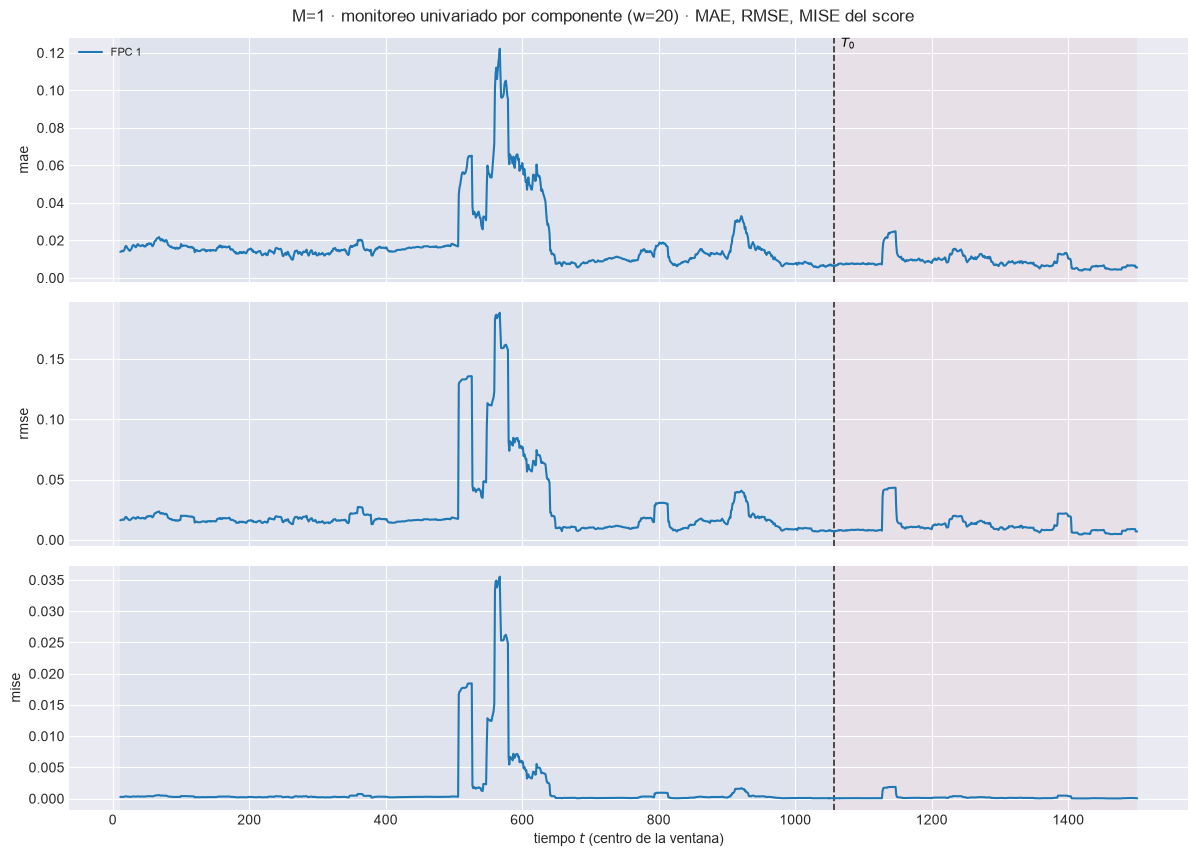

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  mae: w=20 train=0.009455  w=20 test=0.005455
  2/3 (66.7%) t=0.0s eta=0.0s  rmse: w=20 train=0.01101  w=20 test=0.006924
  3/3 (100.0%) t=0.1s eta=0.0s  mise: w=20 train=0.0001213  w=20 test=4.795e-05
[plot_ventana_movil] listo: 3 pasos en 0.6s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v04_m02\91_ventana_univariado.png


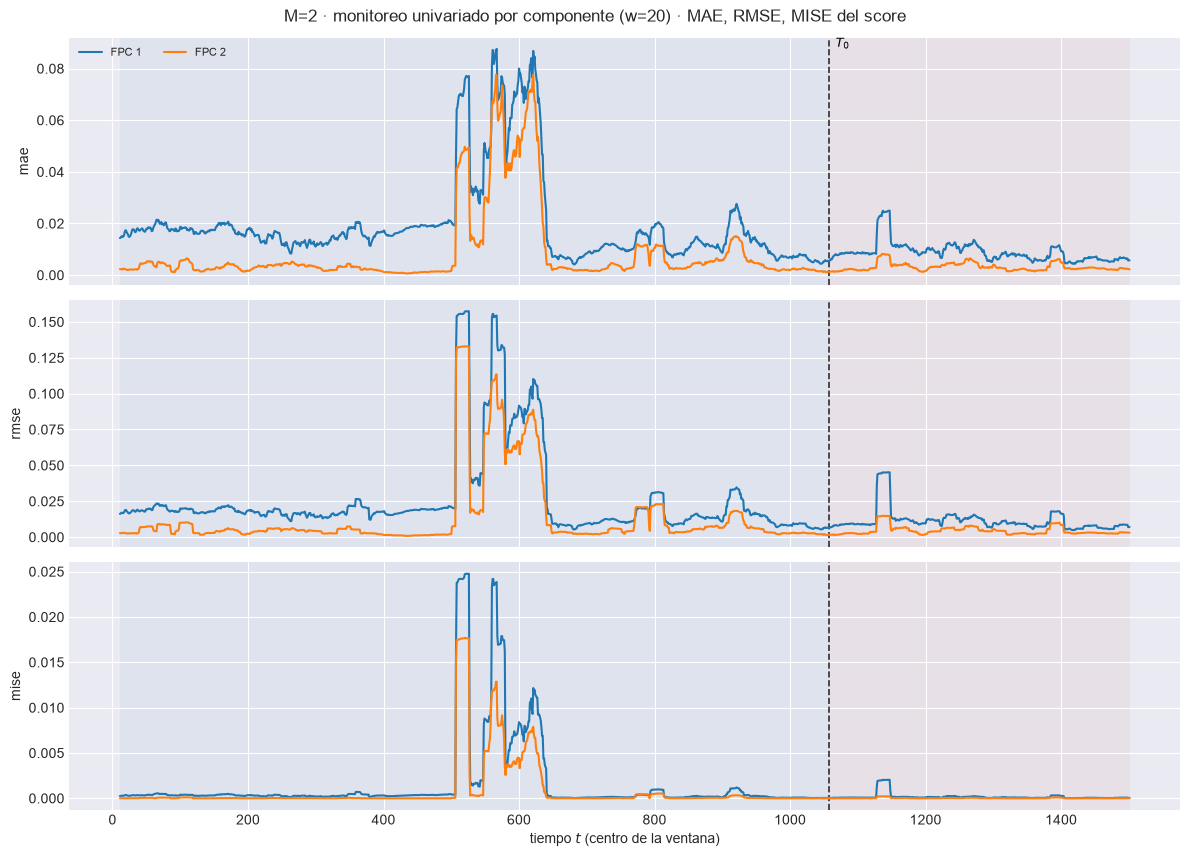

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  mae: w=20 train=0.005008  w=20 test=0.003982
  2/3 (66.7%) t=0.0s eta=0.0s  rmse: w=20 train=0.006662  w=20 test=0.004864
  3/3 (100.0%) t=0.1s eta=0.0s  mise: w=20 train=4.439e-05  w=20 test=2.365e-05
[plot_ventana_movil] listo: 3 pasos en 0.5s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v04_m03\91_ventana_univariado.png


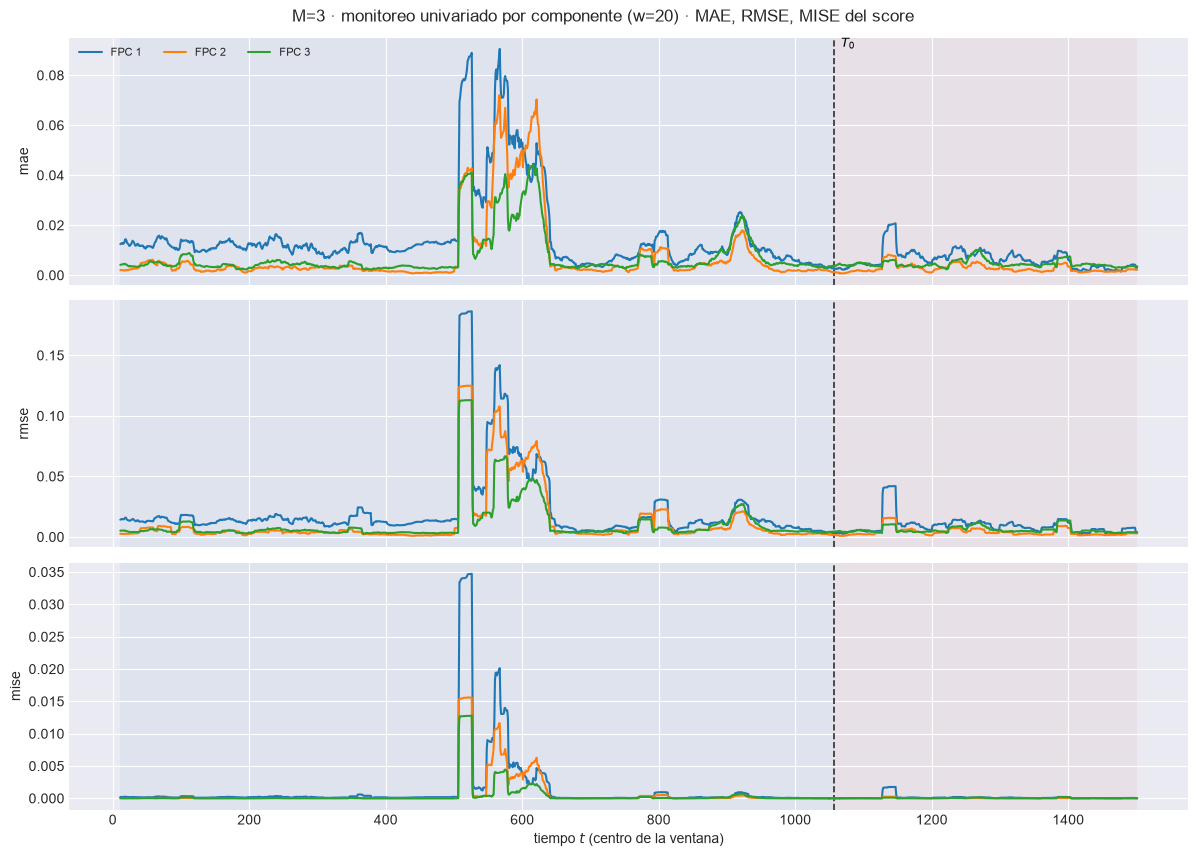

In [23]:
for M in M_OK:
    e = EST[M]
    tsc = e["tablas_score"][W_REF].copy()
    tsc["mise"] = tsc["rmse"] ** 2       # MSE del score: analogo puntual del MISE

    plot_ventana_movil(
        tsc, T0, ["mae", "rmse", "mise"], columna_grupo="componente",
        title=f"M={M} · monitoreo univariado por componente (w={W_REF}) · "
              "MAE, RMSE, MISE del score",
        save_path=str(e["paths"]["out_report"] / "91_ventana_univariado.png"),
        verbose=True)
    plt.show()
